## Settings

In [152]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy
from sklearn.neighbors import LocalOutlierFactor

In [155]:
os.chdir('c:\\Users\\SK\\Desktop\\Sensor_data_analysis\\src\\features')

In [3]:
%matplotlib inline
# plt.style.available
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100

## Load data

In [4]:
df = pd.read_pickle('../../data/interim/01_data_processed.pkl')
df

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set
epoch (ms),,,,,,,,,,
2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,B,bench,heavy,30
2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,B,bench,heavy,30
2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,B,bench,heavy,30
2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,B,bench,heavy,30
2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,B,bench,heavy,30
...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:27.000,-0.048000,-1.041500,-0.076500,1.4146,-5.6218,0.2926,E,row,medium,90
2019-01-20 17:33:27.200,-0.037000,-1.030333,-0.053333,-2.7684,-0.5854,2.2440,E,row,medium,90
2019-01-20 17:33:27.400,-0.060000,-1.031000,-0.082000,2.8416,-5.1342,-0.1220,E,row,medium,90


In [5]:
# Columns to check for outliers
outlier_cols = list(df.columns[:6])
outlier_cols

['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

## 1. InterQuartile Range (IQR) (Distribution-based)

### Boxplot

* Acceleration: Compared to acc_x, acc_y and acc_z show more outliers in general. Especially with acc_z, `bench`, `dead` and `ohp` present extreme outliers, while `row` and `squat` have no outliers at all.

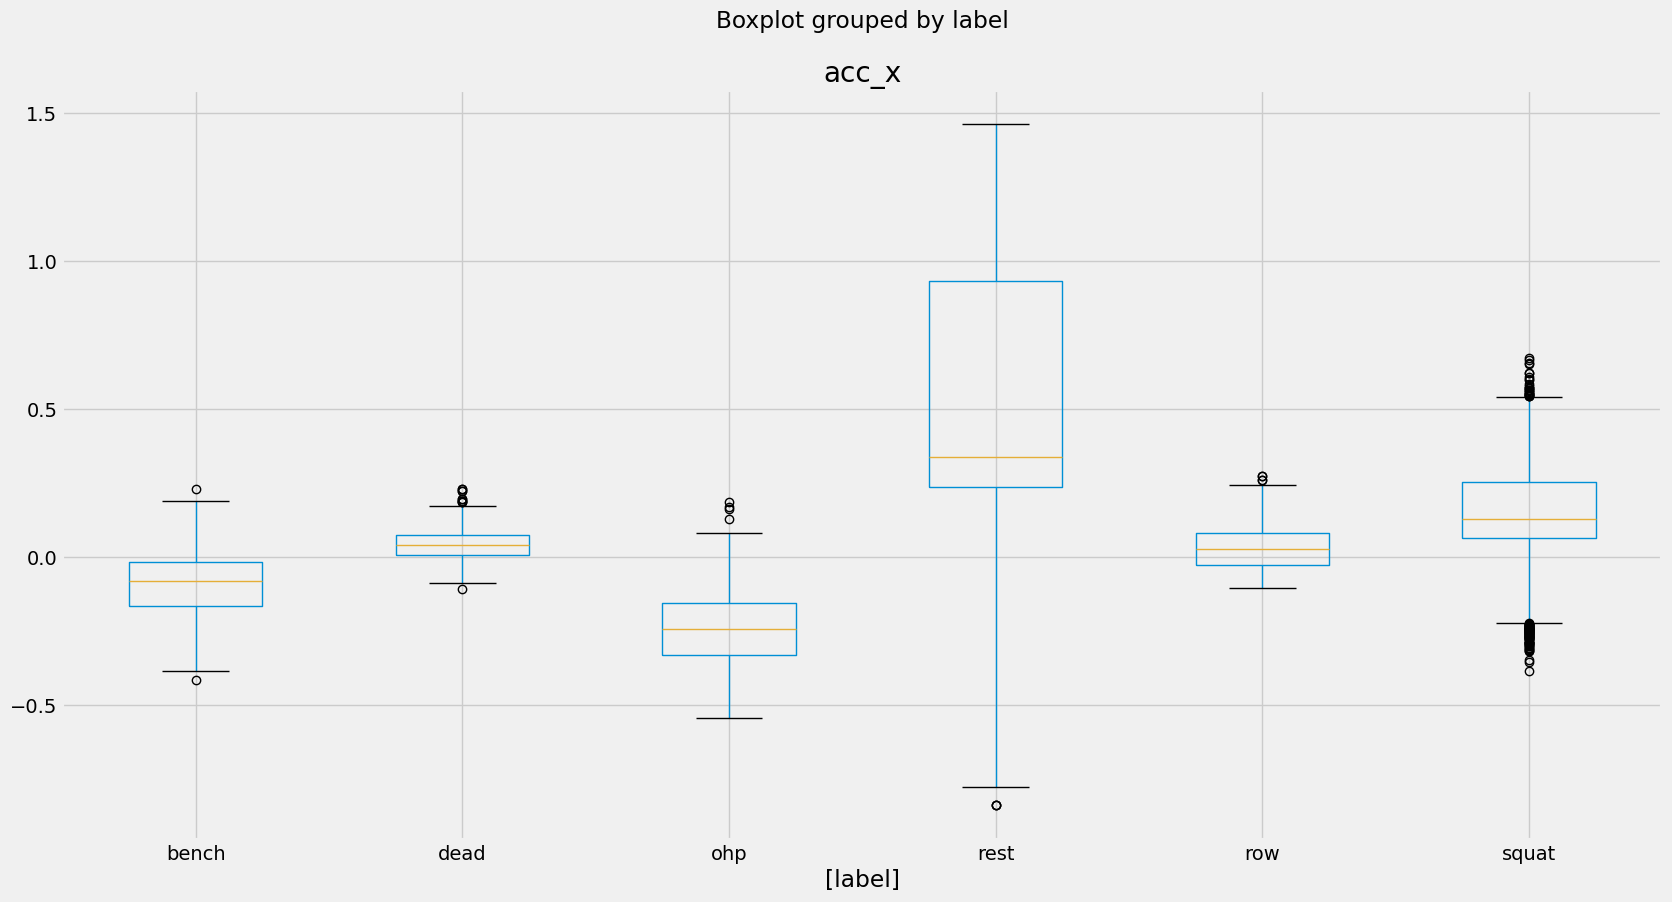

In [6]:
df[['acc_x', 'label']].boxplot(by='label', figsize=(20, 10))    # by: group by
plt.show()

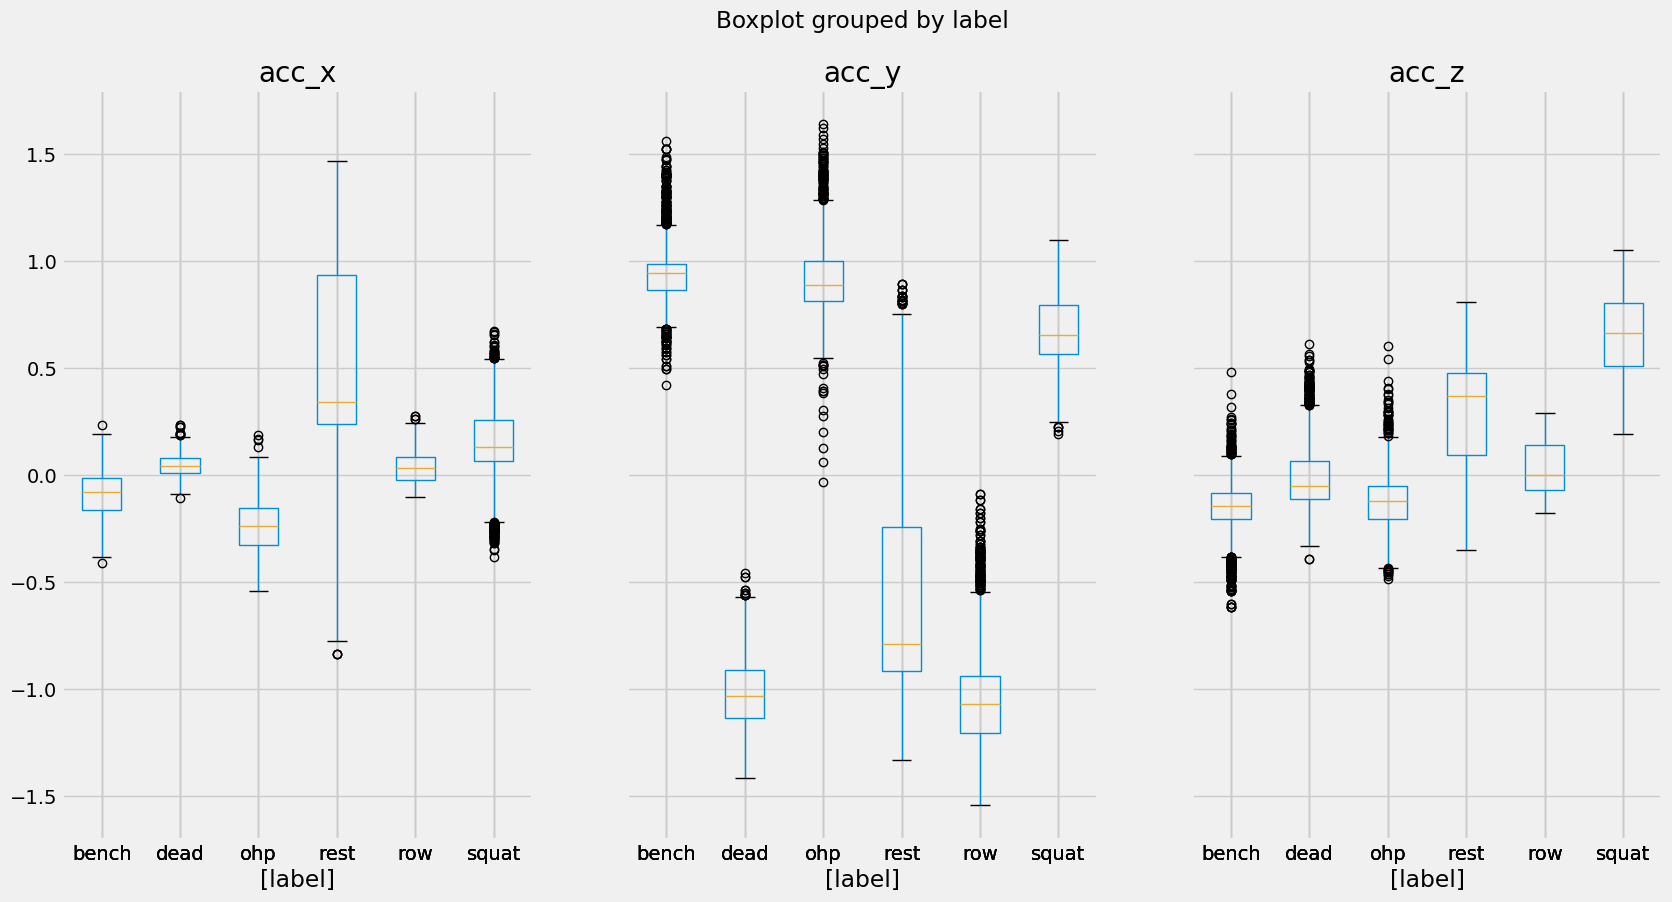

In [7]:
# Put three acceleration features in a boxplot
df[outlier_cols[:3] + ['label']].boxplot(by='label', figsize=(20, 10), layout=(1, 3))    # layout: number of rows and columns
plt.show()

* Angular velocity: All three gyro_x, gyro_y and gyro_z data have many outliers with extremes found in `rest` state.

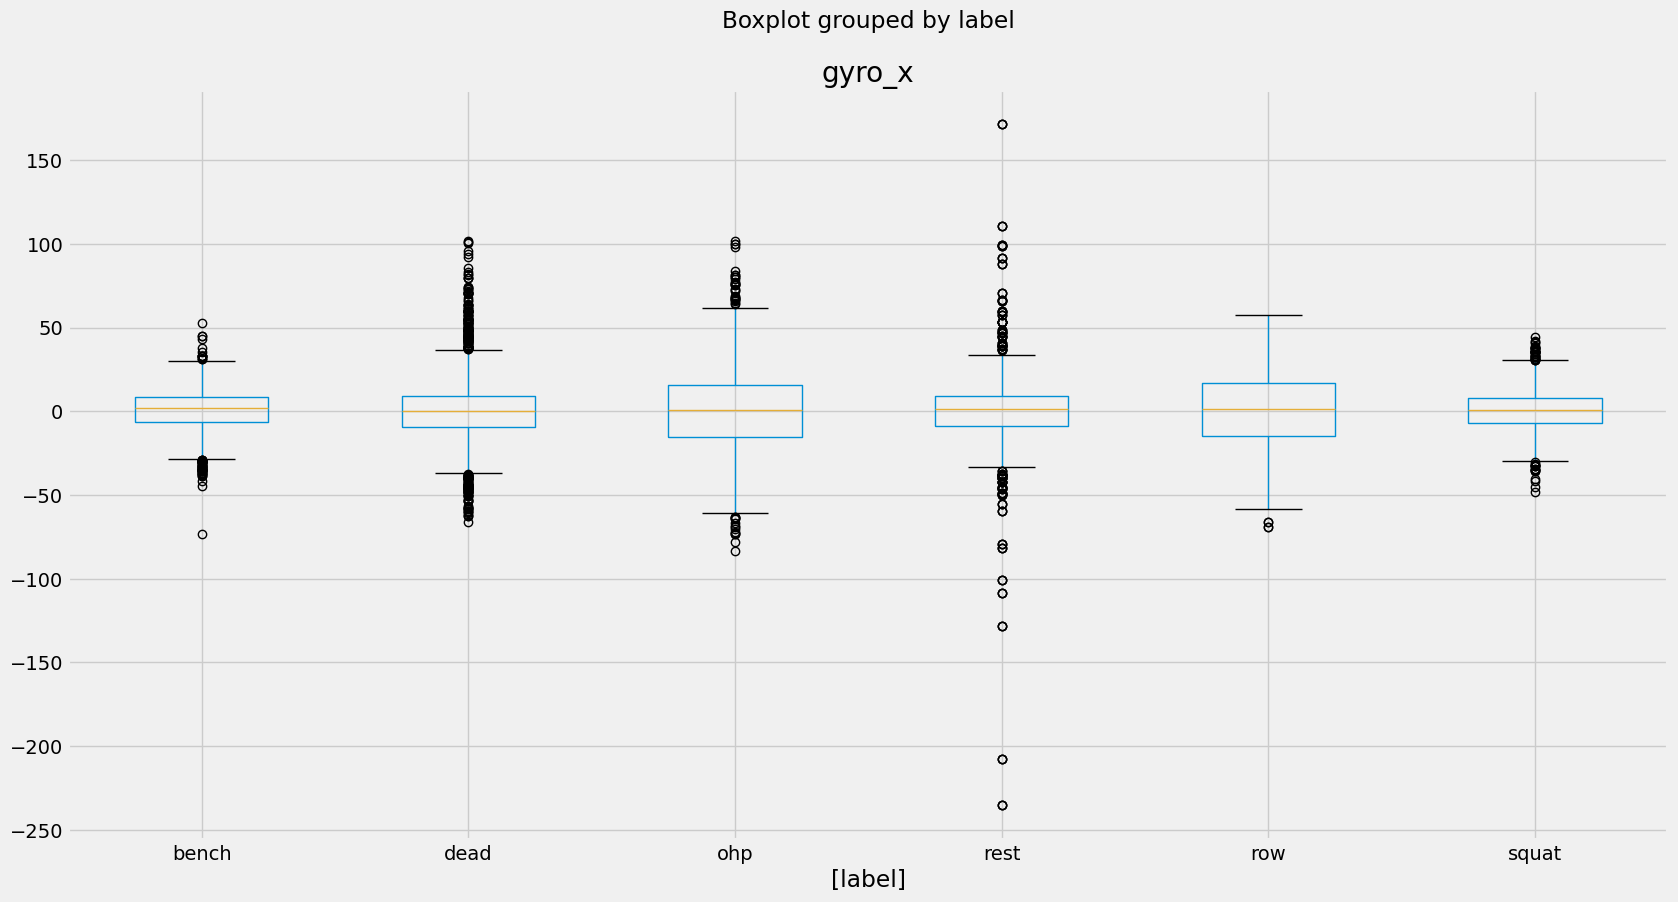

In [8]:
df[['gyro_x', 'label']].boxplot(by='label', figsize=(20, 10))    # by: group by
plt.show()

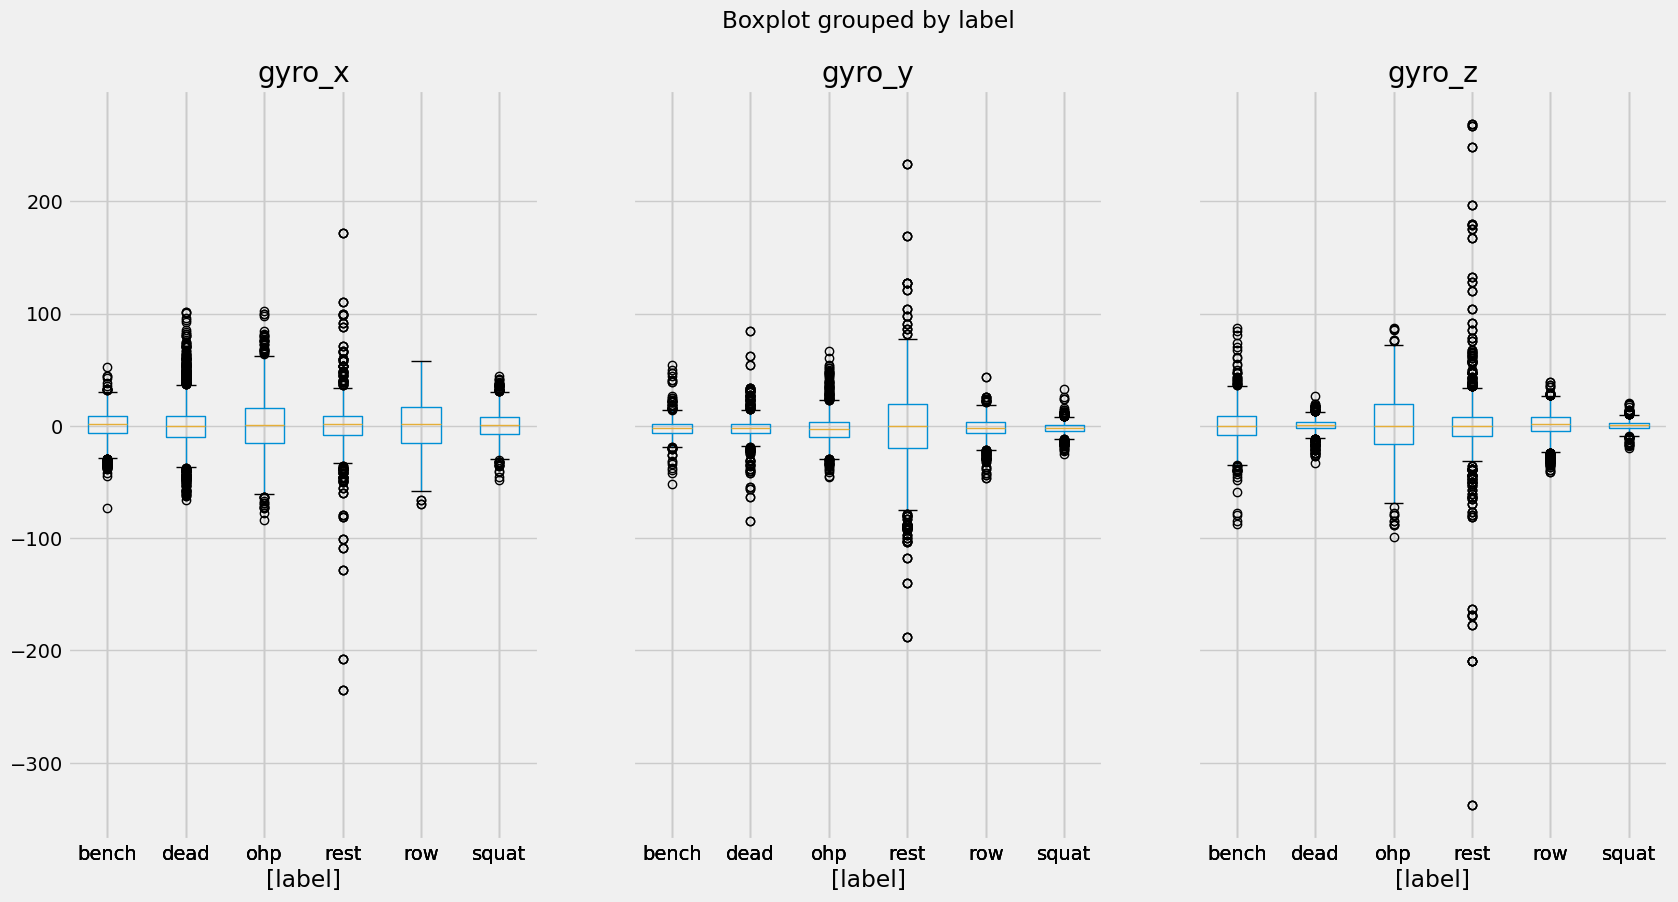

In [9]:
# Put three gyroscope features in a boxplot
df[outlier_cols[3:] + ['label']].boxplot(by='label', figsize=(20, 10), layout=(1, 3))    # by: group by
plt.show()

### Define functions using IQR

It is to visualise data over samples as we did before in the previous data visualisation chapter, but with outliers marked.

In [10]:
def mark_outliers_iqr(dataset, col):
    """Function to mark values as outliers using the IQR method.

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): The column you want apply outlier detection to

    Returns:
        pd.DataFrame: The original dataframe with an extra boolean column 
        indicating whether the value is an outlier or not.
    """

    dataset = dataset.copy()

    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Add new column with boolean values indicating outliers
    dataset[col + '_outlier'] = (dataset[col] < lower_bound) | (dataset[col] > upper_bound)
    
    return dataset

In [11]:
def plot_binary_outliers(dataset, col, outlier_col, reset_index):
    """ Plot outliers from a column with a binary outlier score. Here, the col specifies the real data
    column and outlier_col is the columns with a binary value (outlier or not).

    Taken from: https://github.com/mhoogen/ML4QS/blob/master/Python3Code/util/VisualizeDataset.py

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): Column that you want to plot
        outlier_col (string): Binary column marked with true/false of whether the value is an outlier 
        or not, corresponding to the col column
        reset_index (bool): Whether to reset the index for plotting
    """

    dataset = dataset.dropna(axis=0, subset=[col, outlier_col])
    dataset[outlier_col] = dataset[outlier_col].astype('bool')

    if reset_index:
        dataset = dataset.reset_index()

    fig, ax = plt.subplots()
    plt.xlabel('sample')
    plt.ylabel(f'{col}')

    # Plot non outliers only in default color
    ax.plot(
        dataset.index[~dataset[outlier_col]],
        dataset[col][~dataset[outlier_col]],
        '.'
    )

    # Plot outliers only in red
    ax.plot(
        dataset.index[dataset[outlier_col]],
        dataset[col][dataset[outlier_col]],
        'r+'
    )

    plt.legend(
        ['no outlier ' + col, 'outlier ' + col],
        loc='upper center',
        ncols=2,
        fancybox=True,
        shadow=True
    )
    plt.show()

### Plot the dataframe

* Plot a single column

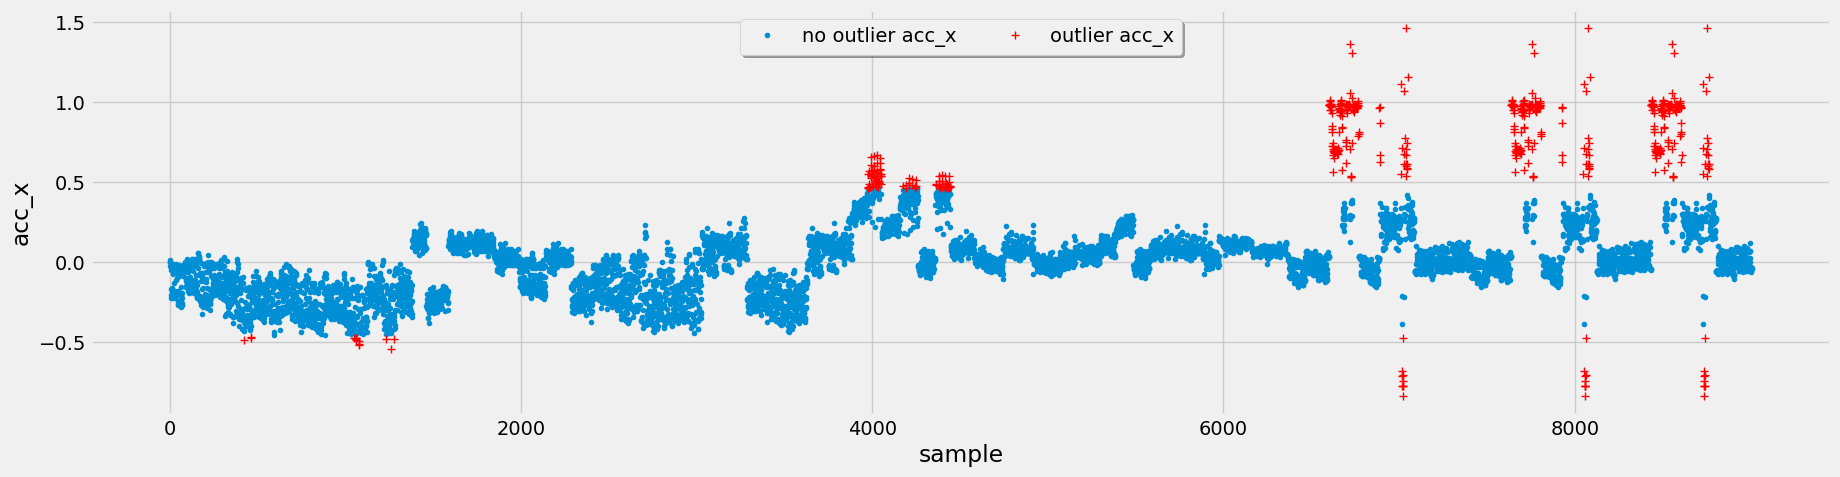

In [12]:
col = 'acc_x'
dataset = mark_outliers_iqr(df, col)
plot_binary_outliers(dataset, col, col+'_outlier', reset_index=True)

* Plot all columns

It is also obvious here that the gyroscope data have more outlier values.

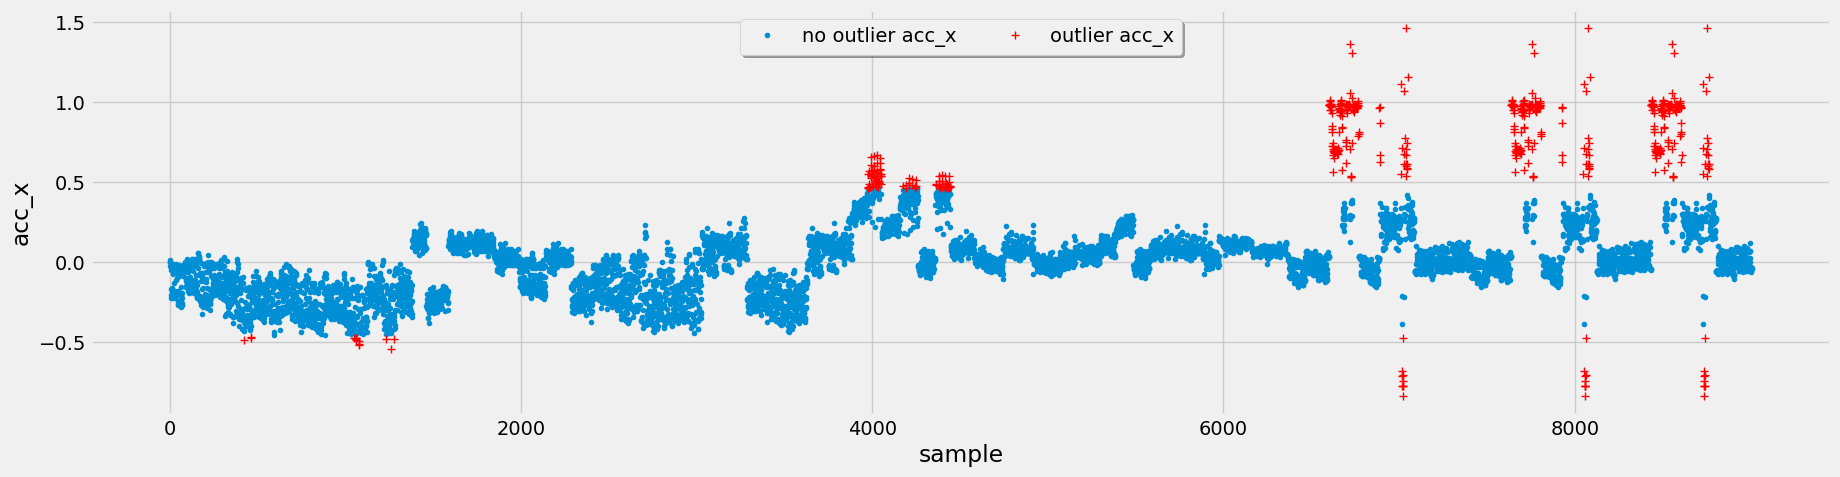

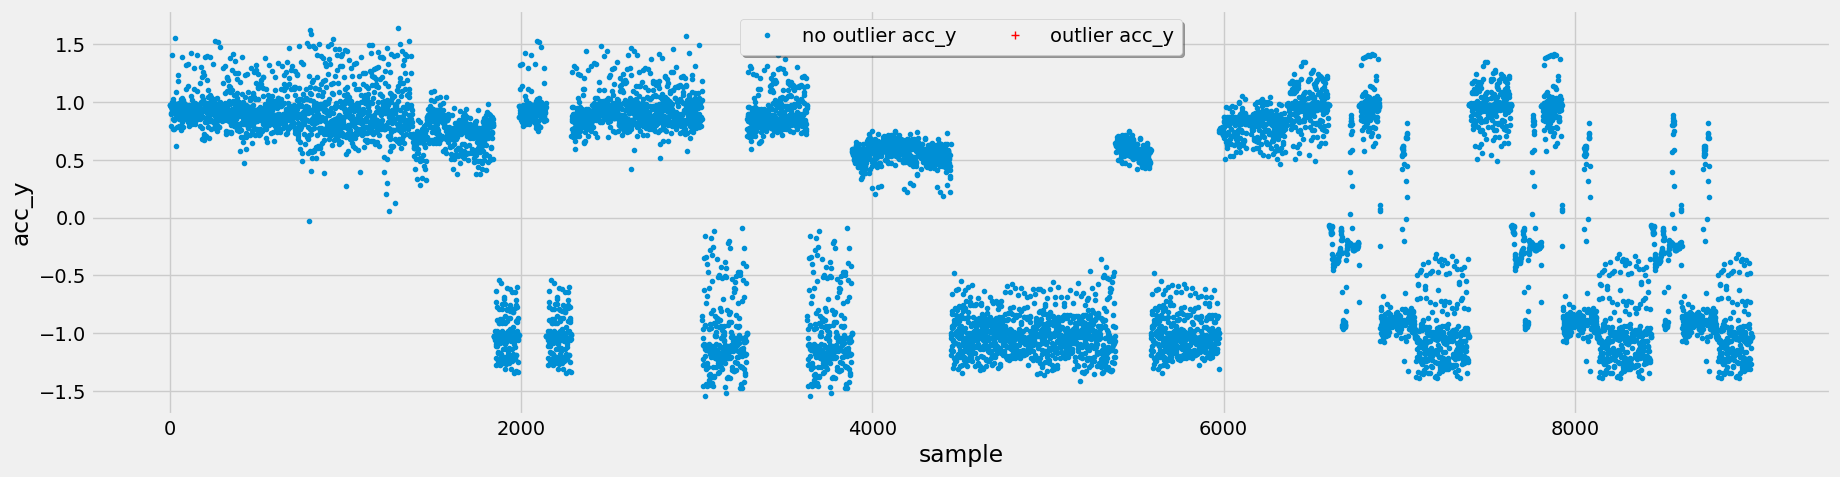

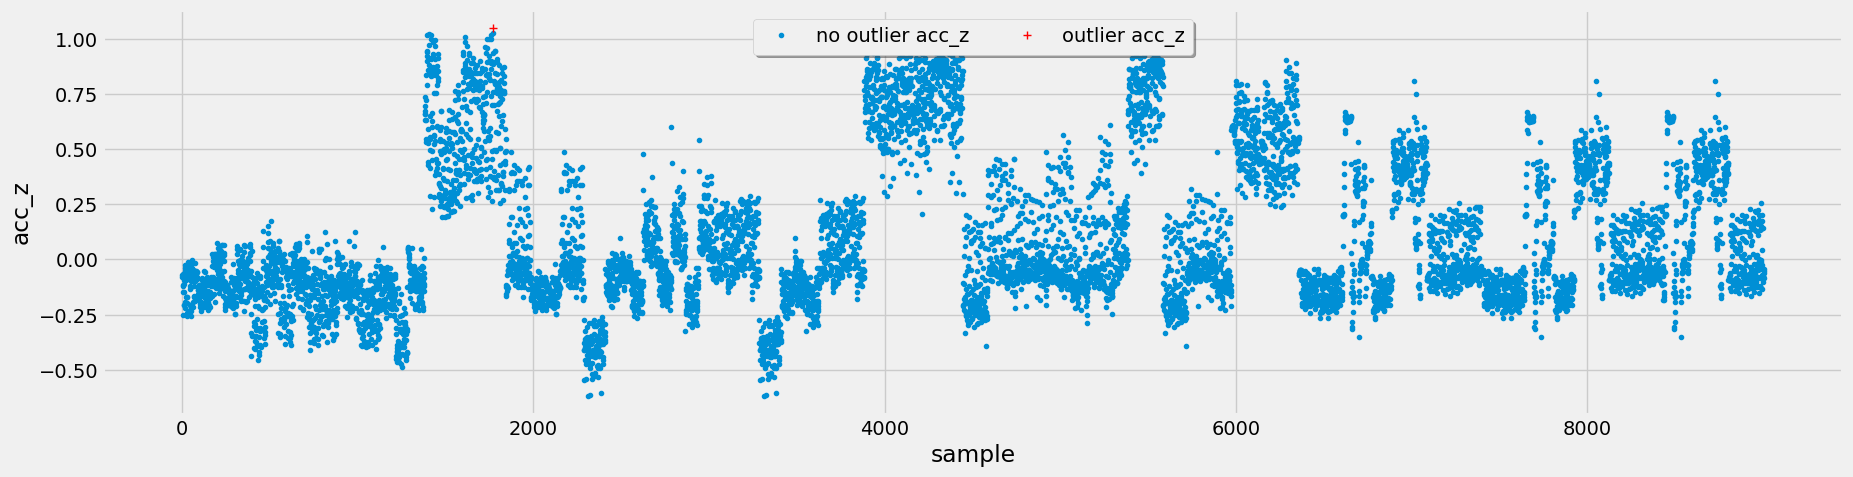

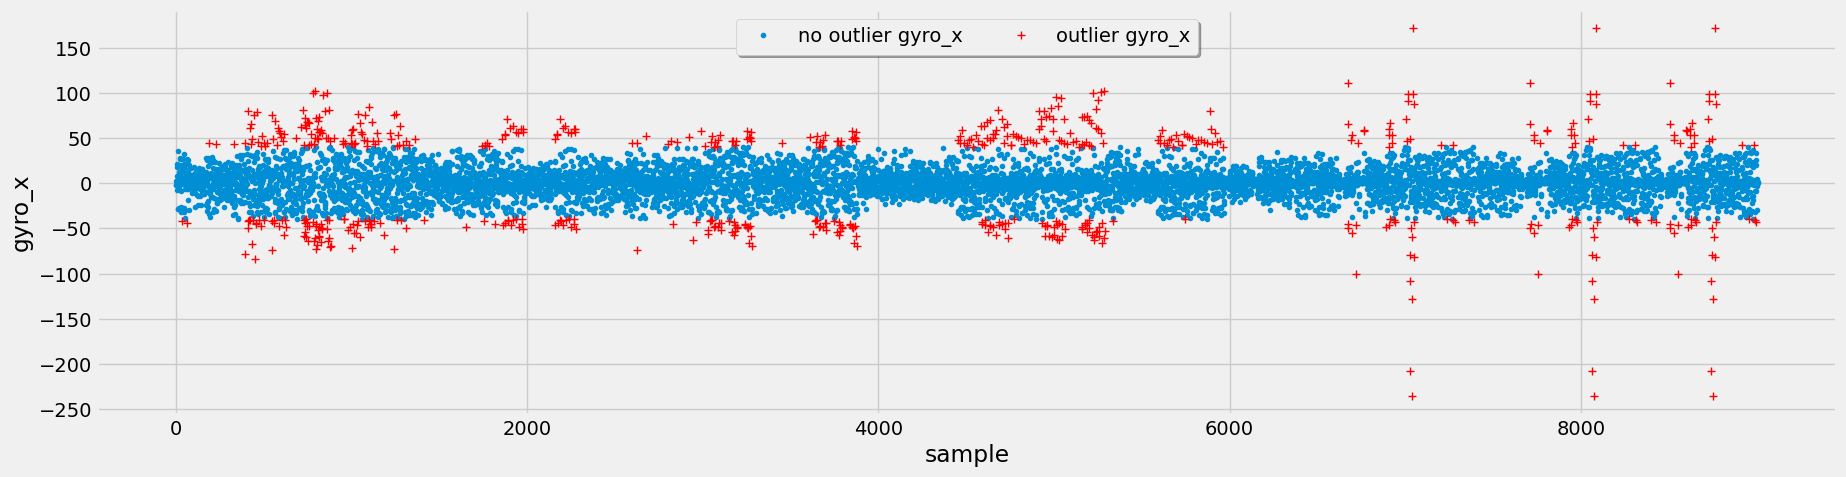

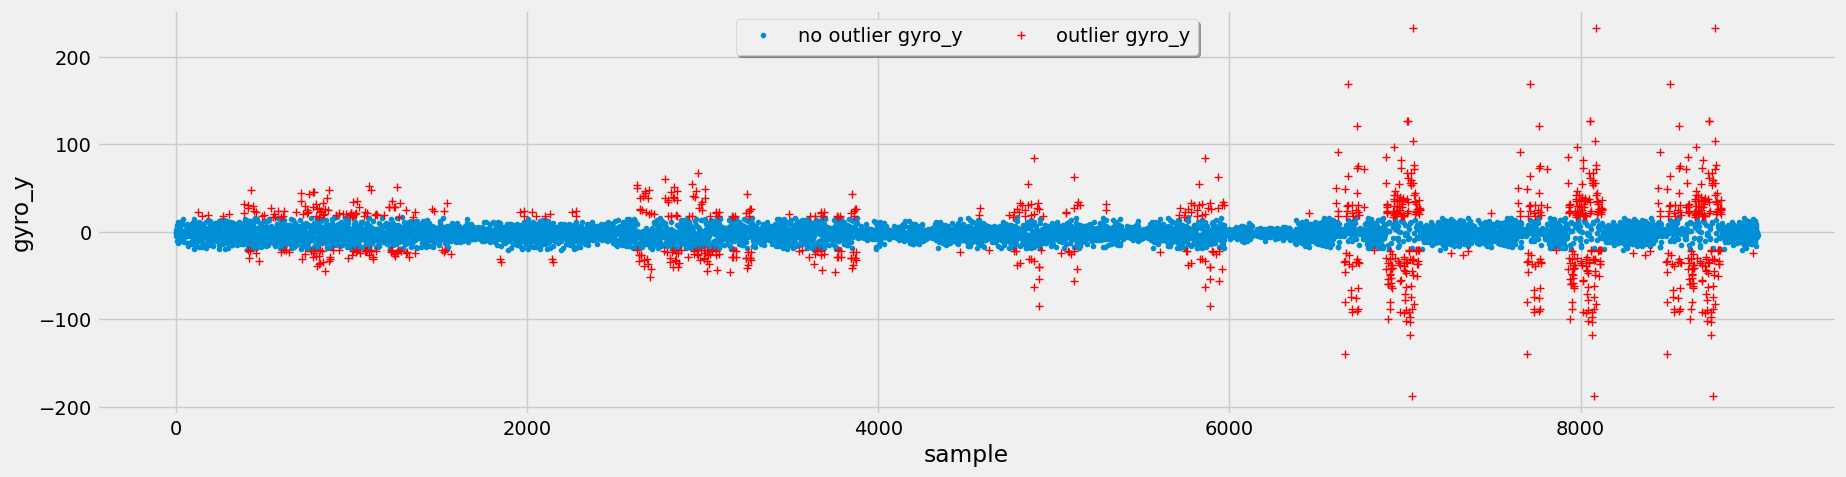

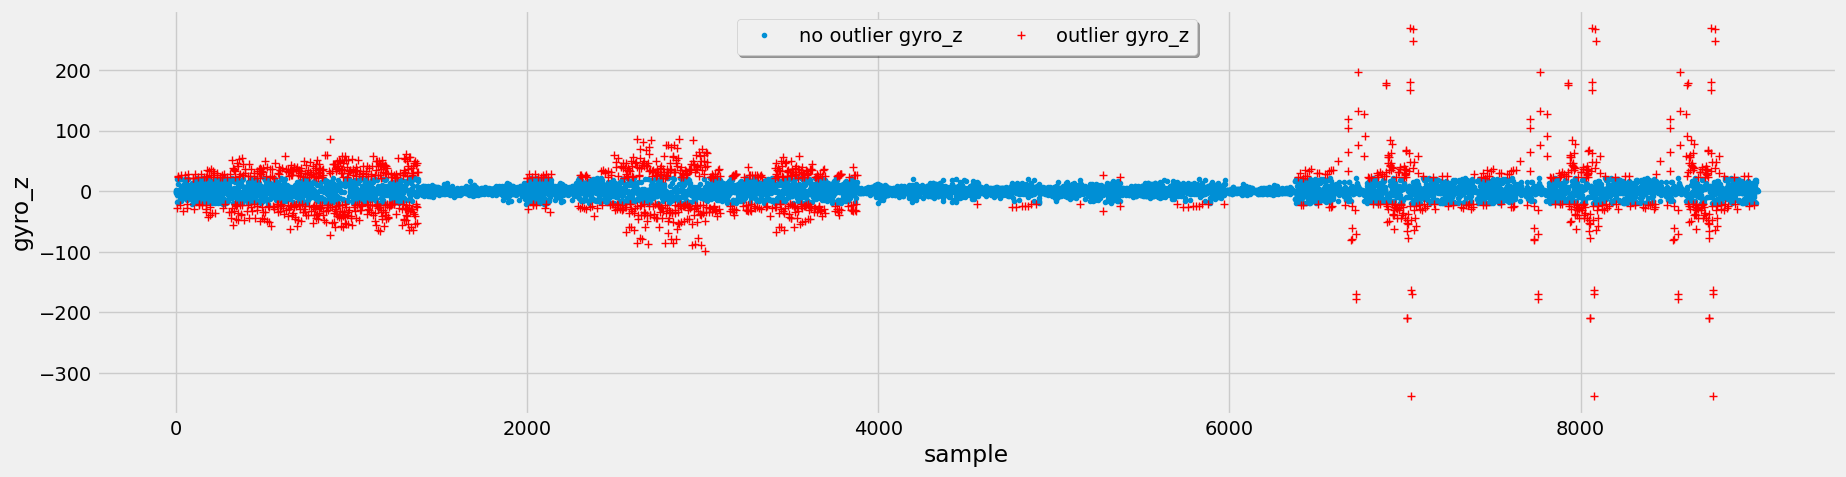

In [13]:
for col in outlier_cols:
    dataset = mark_outliers_iqr(df, col)
    plot_binary_outliers(dataset, col, col+'_outlier', reset_index=True)

> NOTE: Are those claimed outliers the real outliers? Is there anything missing? 
> > Yes, each plot includes all types of exercies, but different exercies can have different range of values as seen in the boxplot. Thus, the data should be divided based on the different exercies.

## 2. Chauvenet's Criterion (Distribution-based)

Chauvenet’s criterion is a way to identify outliers. The method works by creating an acceptable band of data around the mean, specifying any values that fall outside that band should be eliminated. The formula to calculate the acceptable band is: <br>**$(1 - \frac{1}{2n})$**, where n is the sample size; generalization is to replace the value 2 with a parameter C. 

The procedure assumes the data is **normally distributed**.

>Calculation

It is similar to comparing p-value with α (significance value). In this scenario:
- `1/Cn`: significance level
- `τ`: statistics

If `τ` lies in the rejection region, it will be considered as an outlier and rejected.

`τ` is maximum deviation from the mean: <br>**$\tau = \frac{|Xi – x̄|}{s}$** (same as the absolute value of Z-score).

As in t-test, it could be calculated either way of below the two.
1. Find the critical value that meets $\text{P}(- \text{critical value} < X < \text{critical value}) = 1 - \frac{1}{Cn}$. Then, compare with τ. If τ is bigger than the critical value, the datapoint will be rejected.
2. Calculate $\text{P}(- \tau < X < \tau)$ and compare with $(1 - \frac{1}{Cn})$. If $1 - \text{P}(- \tau < X < \tau) < \frac{1}{Cn}$, the data point will be rejected.

Here, the second way will be used for calculation.

###  Confirm normal distribution

C:\Users\SK\AppData\Local\Temp\ipykernel_10088\3928974952.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df[outlier_cols[:3] + ['label']].plot.hist(by='label', figsize=(20, 20), layout=(3, 3))
C:\Users\SK\AppData\Local\Temp\ipykernel_10088\3928974952.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df[outlier_cols[3:] + ['label']].plot.hist(by='label', figsize=(20, 20), layout=(3, 3))


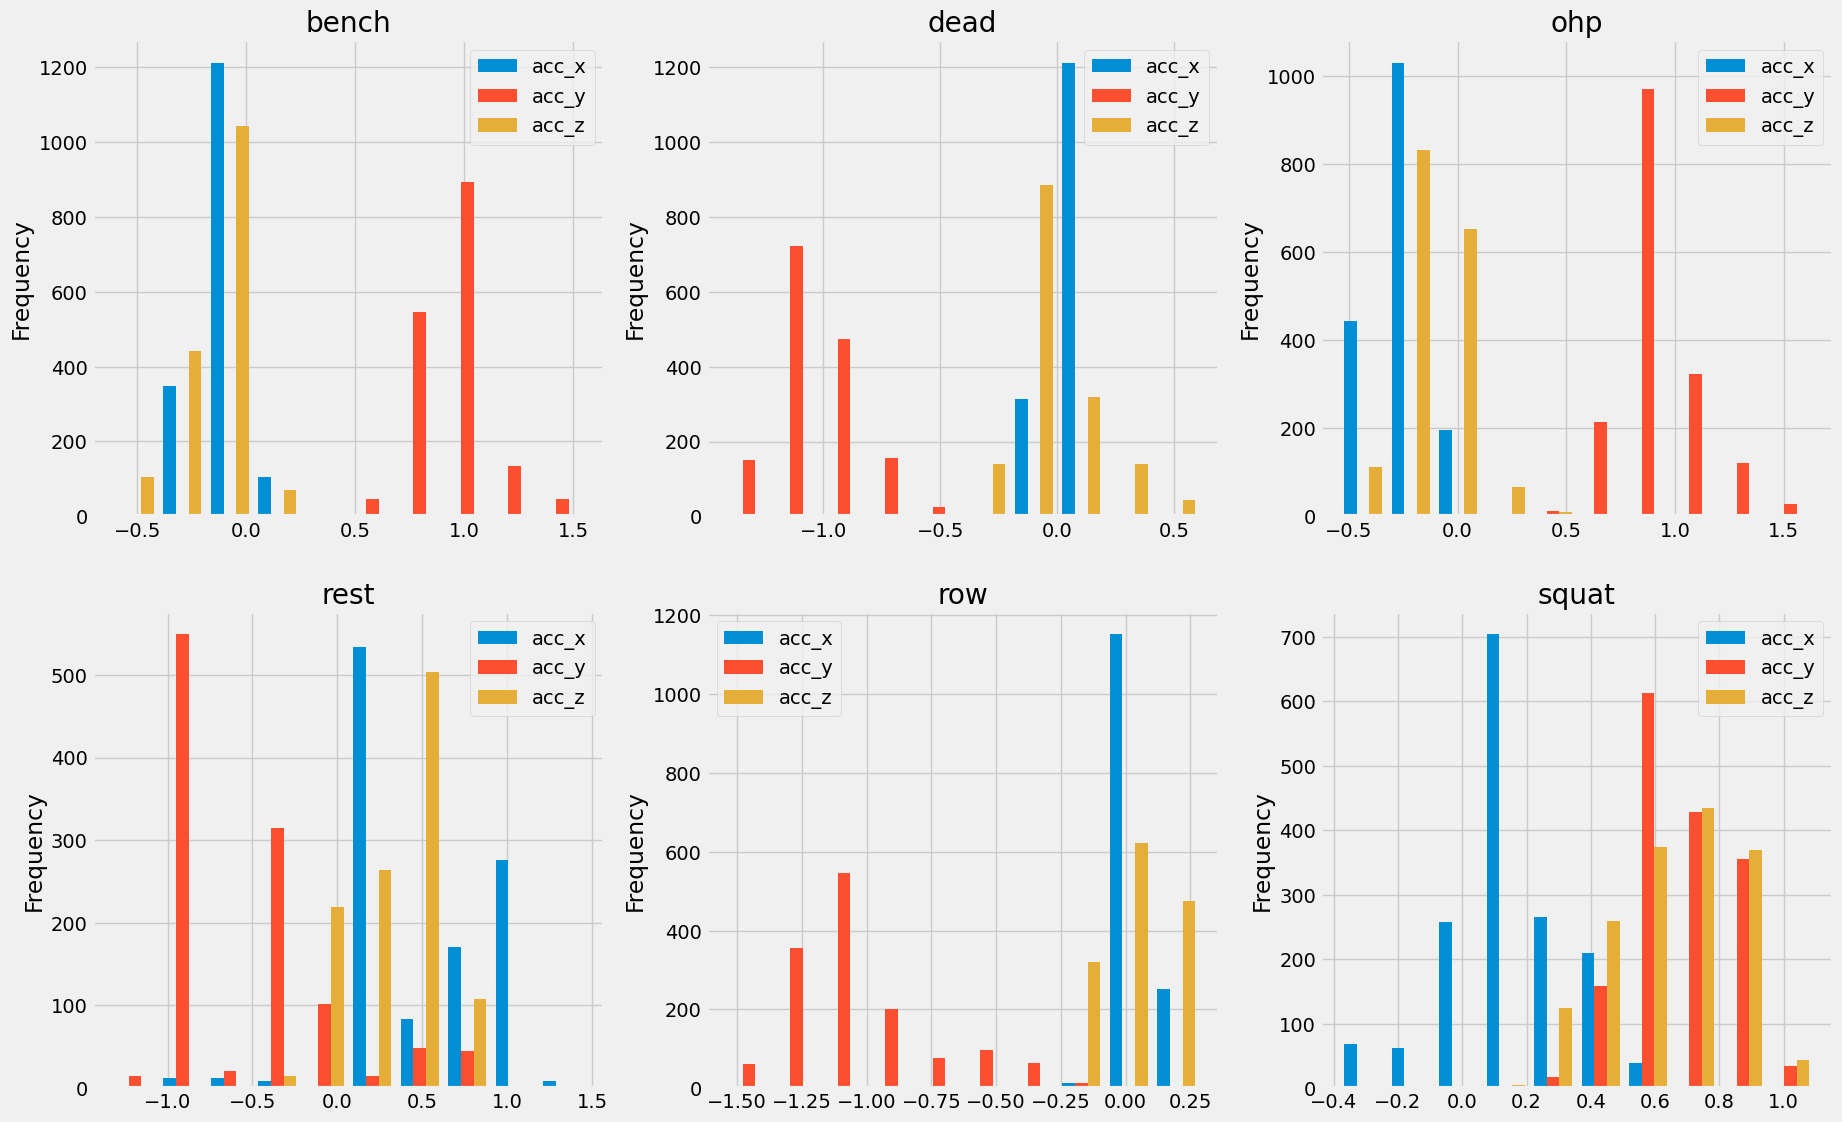

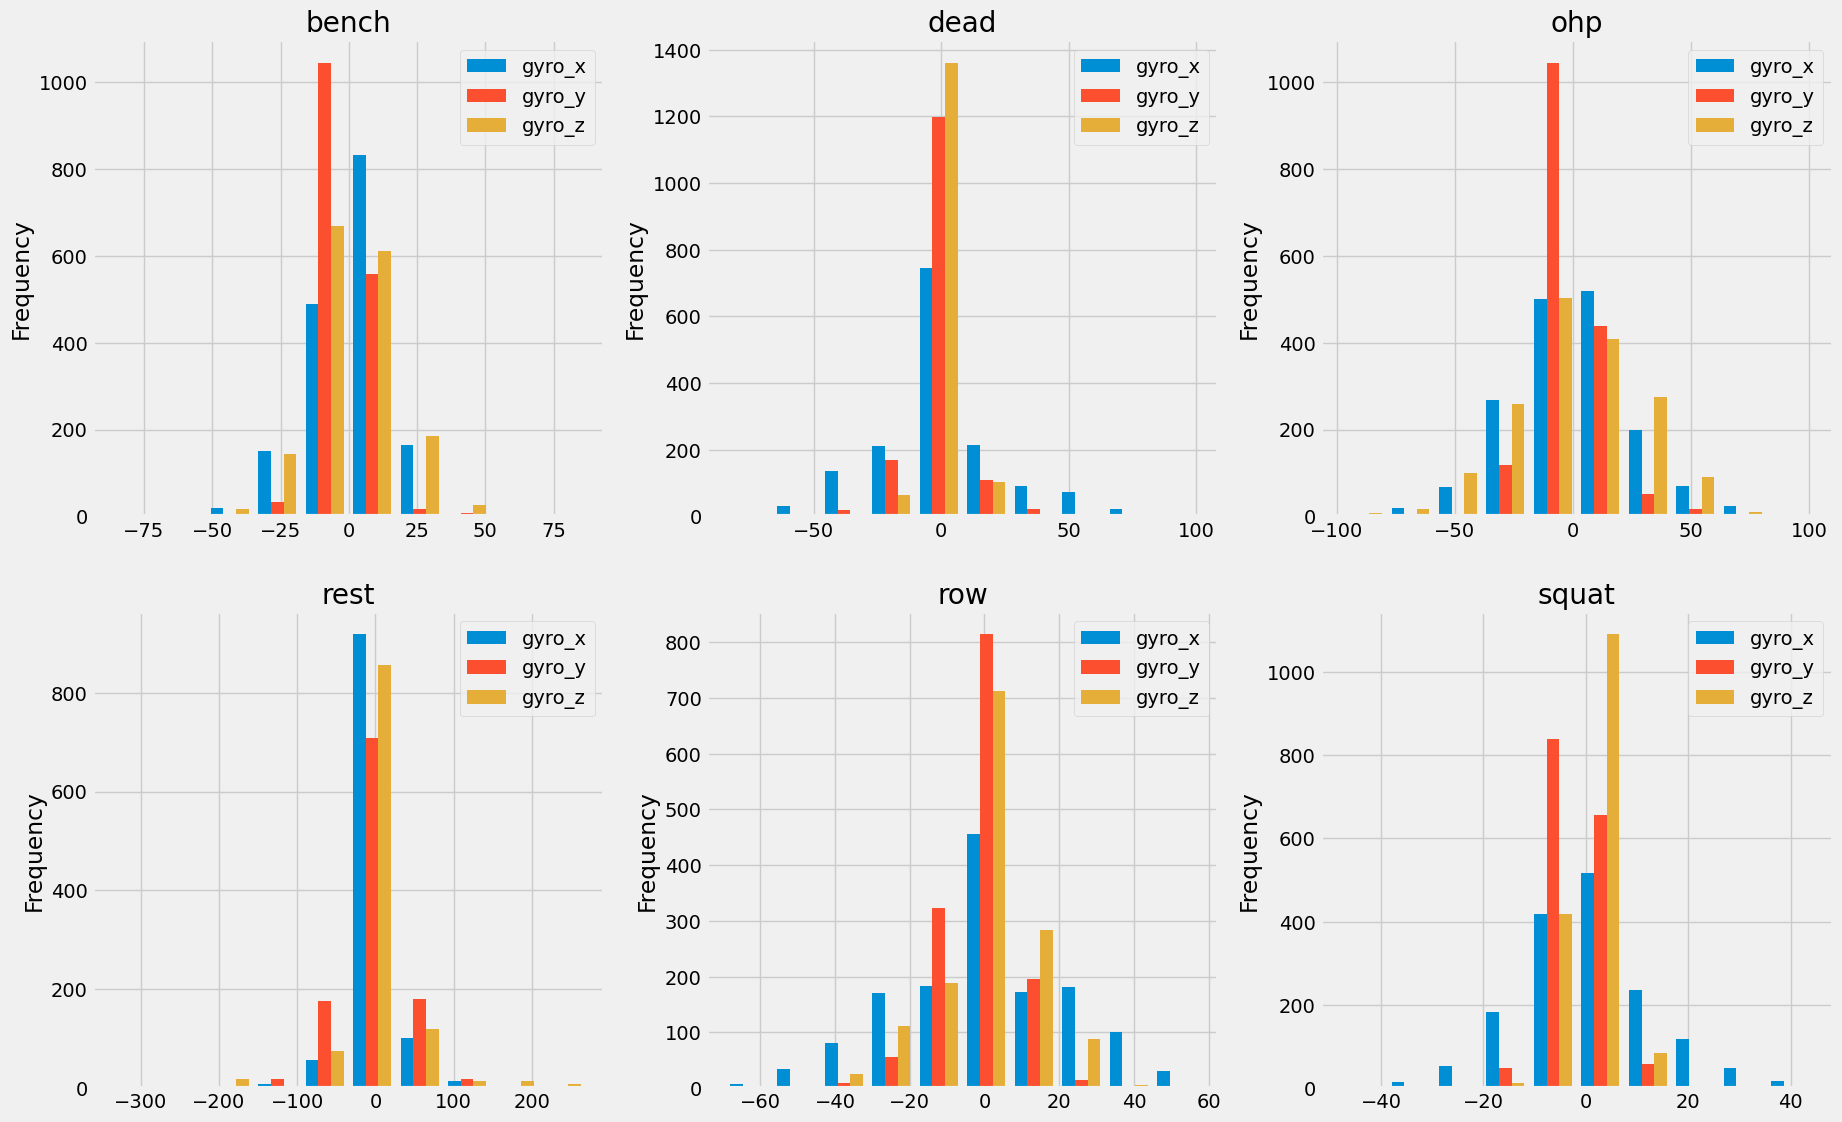

In [14]:
# dataframe.hist(): histogram without legend
df[outlier_cols[:3] + ['label']].plot.hist(by='label', figsize=(20, 20), layout=(3, 3))
df[outlier_cols[3:] + ['label']].plot.hist(by='label', figsize=(20, 20), layout=(3, 3))
plt.show()

### Define functions for Chauvenet's Criterion

> P(- deviation < X < deviation) calculation

Error function (erf) calculates the probability that a normally distributed variable with a mean of 0 will fall within a specific range. 

For normal distribution $\text{N}(0, α), \text{P}(-x < X < x) = \text{erf}(\frac{x}{α\sqrt{2}})$.

To apply in this problem following $\text{N}(0, 1)$ after calculating `τ`, $\text{P}(-d < X < d) = \text{erf}(\frac{d}{1*\sqrt{2}}) = \text{erf}(\text{high})$.

> Alternative way

Normal cumulative distribution function: $\Phi(x) = \frac{1}{2} [1 + \text{erf}(\frac{x}{\sqrt{2}})]$.

P(- deviation < X < deviation) can be calculated using the formula above.

$$
\begin{aligned}
\text{P}(-d < X < d) &= \Phi(d) - \Phi(-d) \\
&= \frac{1}{2} \left[ 1 + \text{erf}\left(\frac{d}{\sqrt{2}}\right) \right] - \frac{1}{2} \left[ 1 + \text{erf}\left(\frac{-d}{\sqrt{2}}\right) \right] \\
&= \frac{1}{2} \left[ \text{erf}\left(\frac{d}{\sqrt{2}}\right) - \text{erf}\left(\frac{-d}{\sqrt{2}}\right) \right] \\
&= \frac{1}{2} \left[ \text{erf}(\text{high}) - \text{erf}(\text{low}) \right]
\end{aligned}
$$

As in erf(-x) = - erf(x), both ways have the same result.

In [34]:
def mark_outliers_chauvenet(dataset, col, C=2):
    """Finds outliers in the specified column of dataframe and adds a binary column with
    suffix '_outlier' that indicates outlier or not per data point.
    
    Taken from: https://github.com/mhoogen/ML4QS/blob/master/Python3Code/Chapter3/OutlierDetection.py

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): The column you want apply outlier detection to
        C (int, optional): Degree of certainty for the identification of outliers given the assumption 
                           of a normal distribution, typicaly between 1 - 10. Defaults to 2.

    Returns:
        pd.DataFrame: A new dataframe with an extra boolean column 
        indicating whether the value is an outlier or not.
    """

    dataset = dataset.copy()

    mean = dataset[col].mean()
    std = dataset[col].std()
    N = len(dataset.index)
    criterion = 1.0 / (C * N)

    # Calculate the deviation for data points
    deviation = abs(dataset[col] - mean) / std

    # Calculate the upper and lower bounds of
    high = deviation / math.sqrt(C)

    rej_prob, rej_mask = [], []

    # Loop over all rows in the dataset
    for i in range(len(dataset)):
        # Rejection region: 1 - P(-d < X < d)
        rej_prob.append(1.0 - scipy.special.erf(high.values[i]))
        # Mark outlier when the probability is smaller than our criterion
        rej_mask.append(rej_prob[i] < criterion)
    
    dataset[col + '_outlier'] = rej_mask
    return dataset

### Loop over all columns

Far less outliers are detected compared to IQR method. Still, each figure contains all types of exercises data.

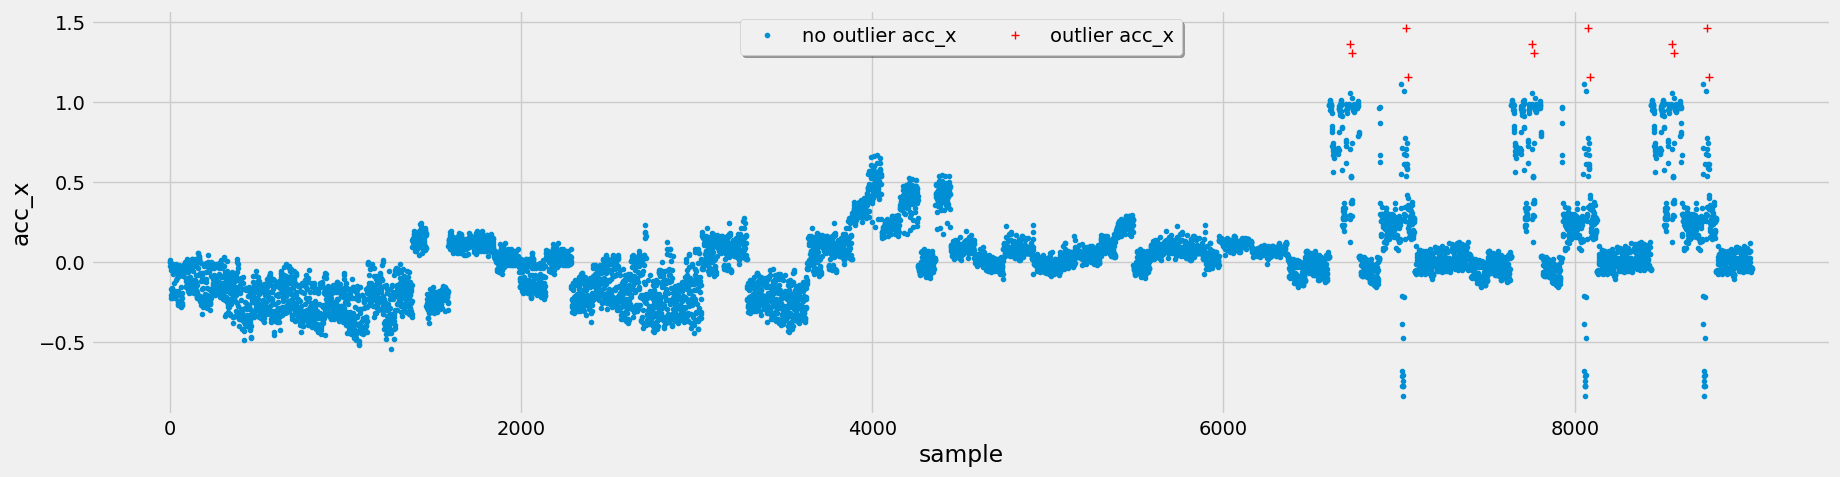

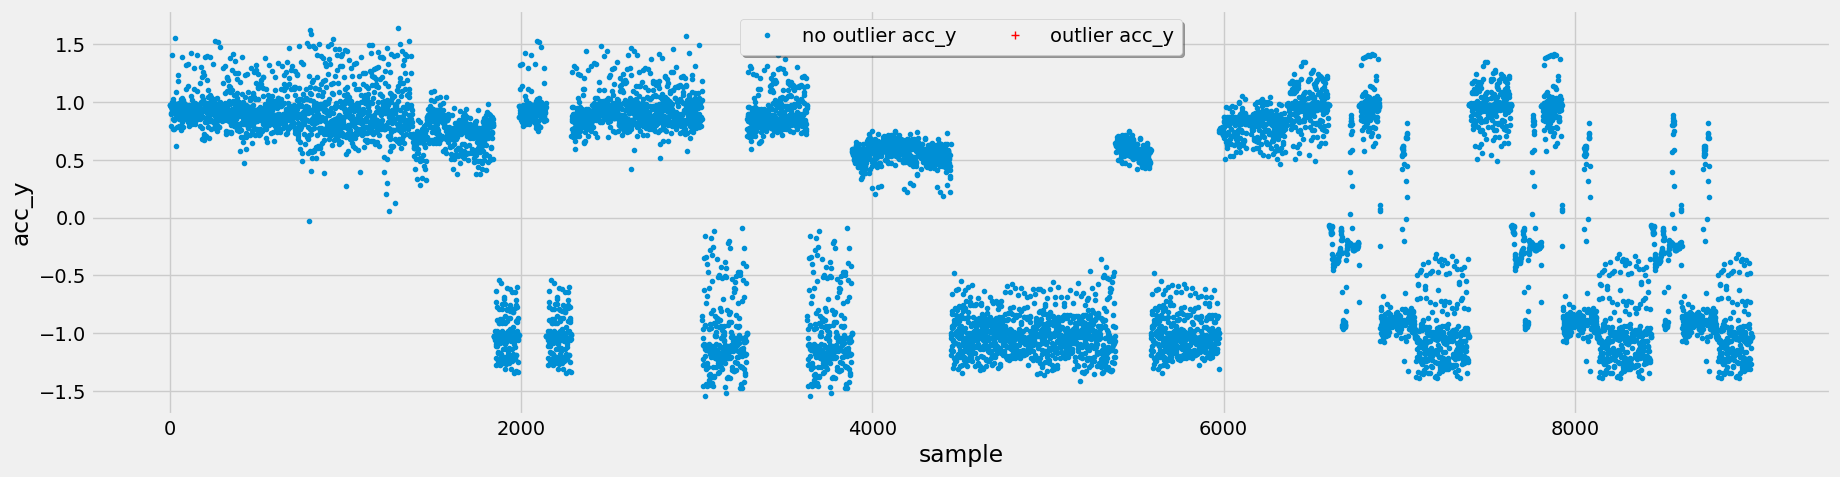

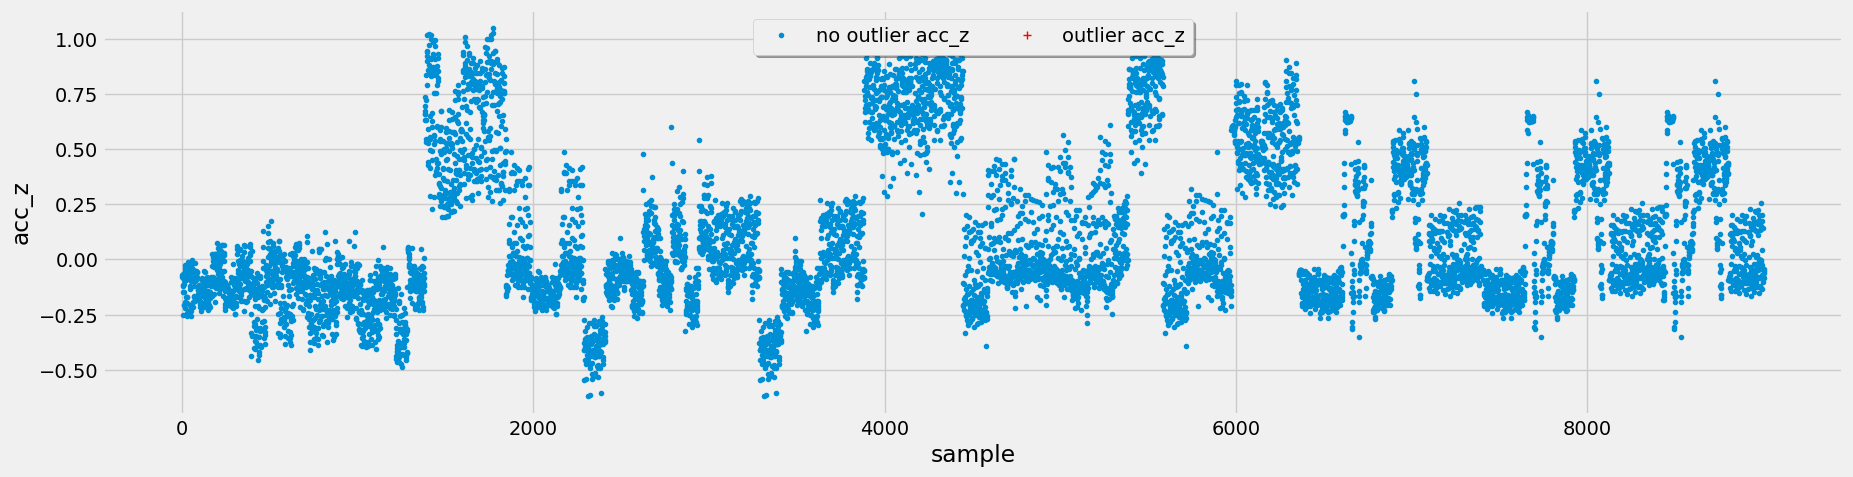

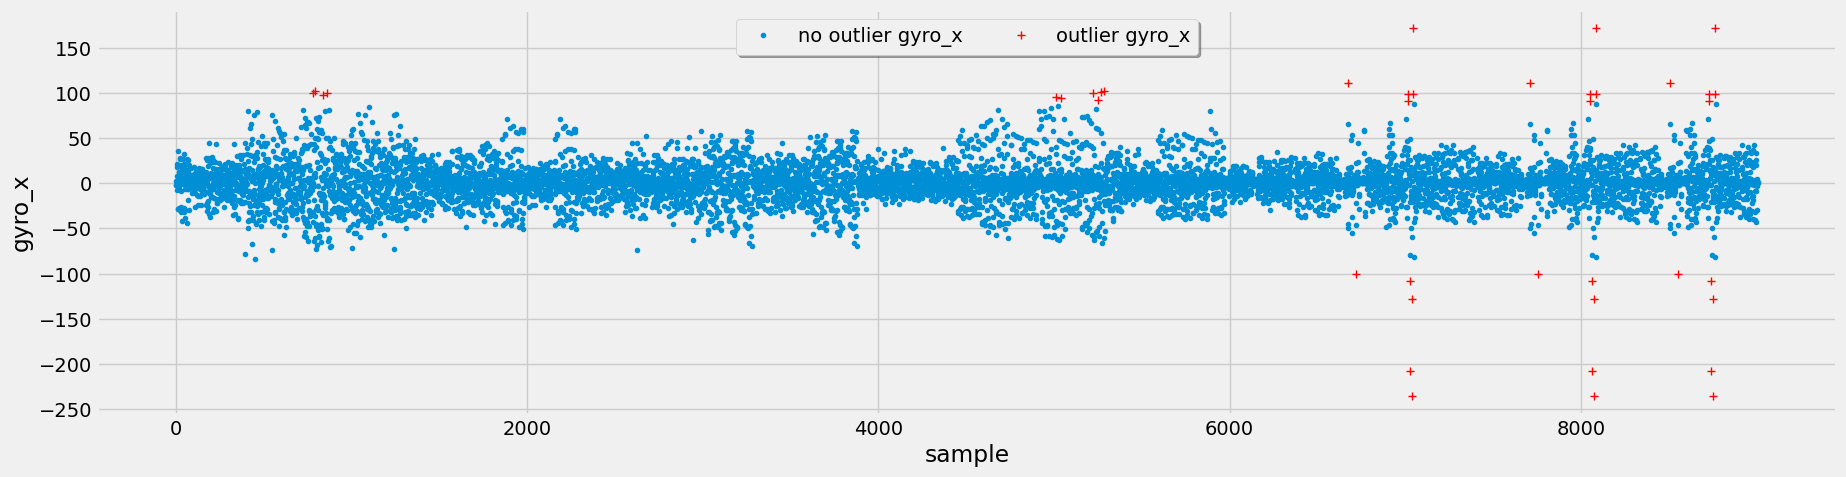

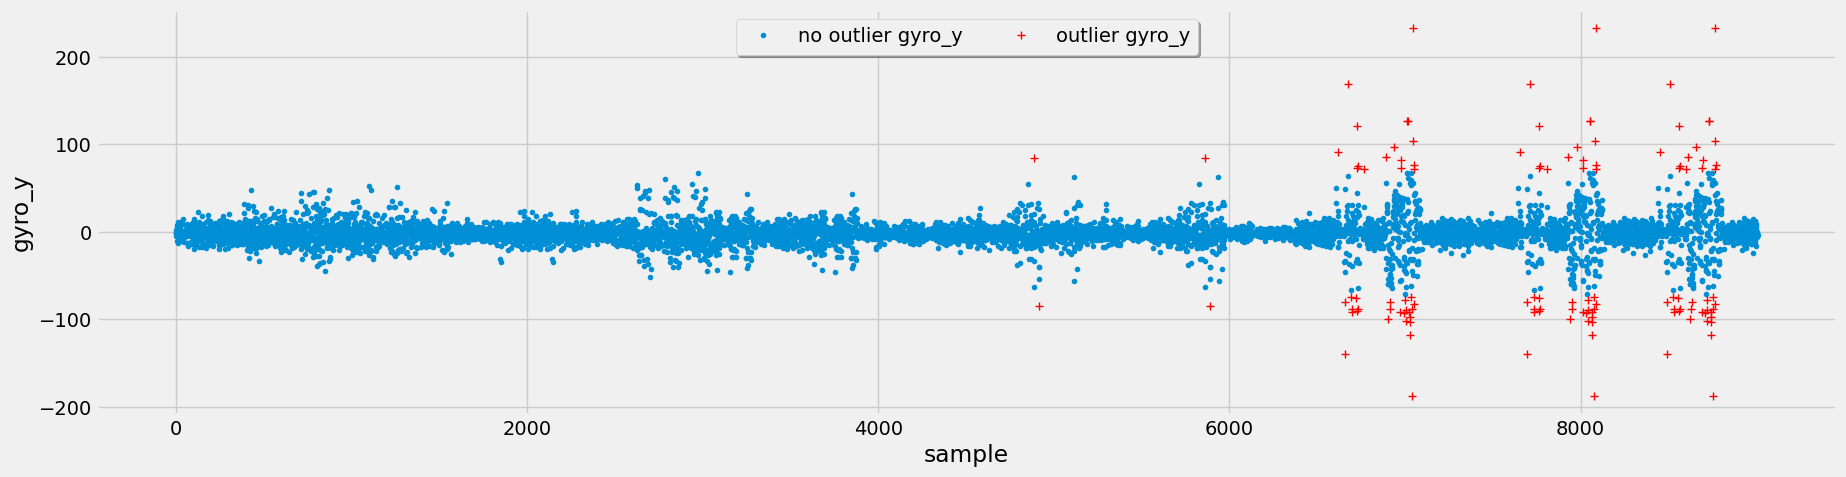

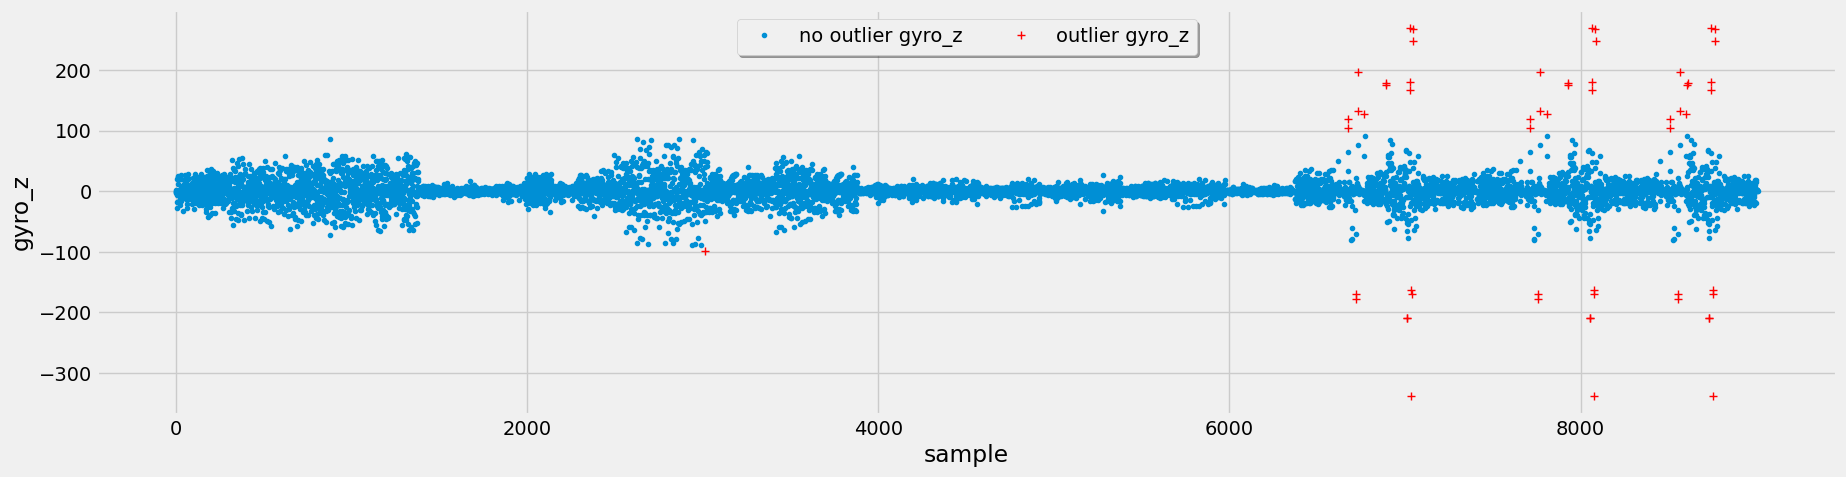

In [36]:
for col in outlier_cols:
    dataset = mark_outliers_chauvenet(df, col)
    plot_binary_outliers(dataset, col, col+'_outlier', reset_index=True)

## 3. Local Outlier Facter (Distance-based)

Unsupervised Outlier Detection using the Local Outlier Factor (LOF).

The anomaly score of each sample is called the Local Outlier Factor. It measures the local deviation of the density of a given sample with respect to its neighbors. It is local in that the anomaly score depends on how isolated the object is with respect to the surrounding neighborhood. More precisely, locality is given by k-nearest neighbors, whose distance is used to estimate the local density. By comparing the local density of a sample to the local densities of its neighbors, one can identify samples that have a substantially lower density than their neighbors. These are considered outliers.

The LOF ratio is **(local reachability density of k-nearest neighbors) / (local reachability density of a sample)**. Thus, **inliners have a smaller LOF score (close to 1), while outliers have a larger LOF score**. However, the `scikit-learn` package follows the convention that all scoring functions are higher-is-better (more likely to be an inlier). So, `negative_outlier_factor_` takes negative values of LOF ratio to achieve this.

> NOTE: Unlike the previous methods, it considers each data point as a coordinate in 6-dimensional space, rather than calculating column-wise.

In [83]:
def mark_outliers_lof(dataset, columns, n=20):
    """Mark values as outliers using LOF.

    Args:
        dataset (pd.DataFrame): The dataset
        col (list of strings): The columns you want apply outlier detection to
        n (int, optional): n_neighbors. Defaults to 20.
    
    Returns:
        pd.DataFrame: A new dataframe with an extra boolean column
        indicating whether the value is an outlier or not.
    """
    
    dataset = dataset.copy()

    lof = LocalOutlierFactor(n_neighbors=n)
    data = dataset[columns]
    outliers = lof.fit_predict(data)          # 1: inliner, -1: anomaly
    # X_scores = lof.negative_outlier_factor_   # -1: inliner, smaller: anomaly

    dataset['lof_outlier'] = (outliers == -1)
    return dataset

Since all 6 columns share the same mask of whether it's outlier or not, all features share the same outlier label per data point. Also, the outliers are detected inside other inliners in each graph.

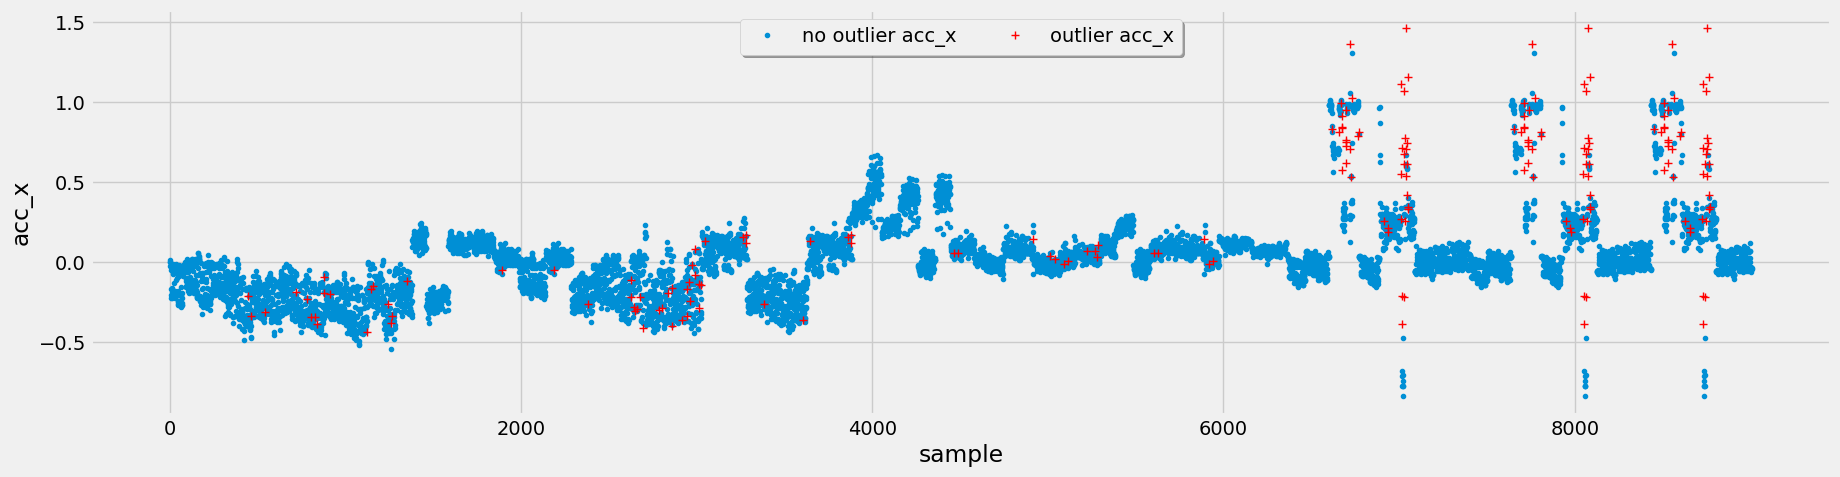

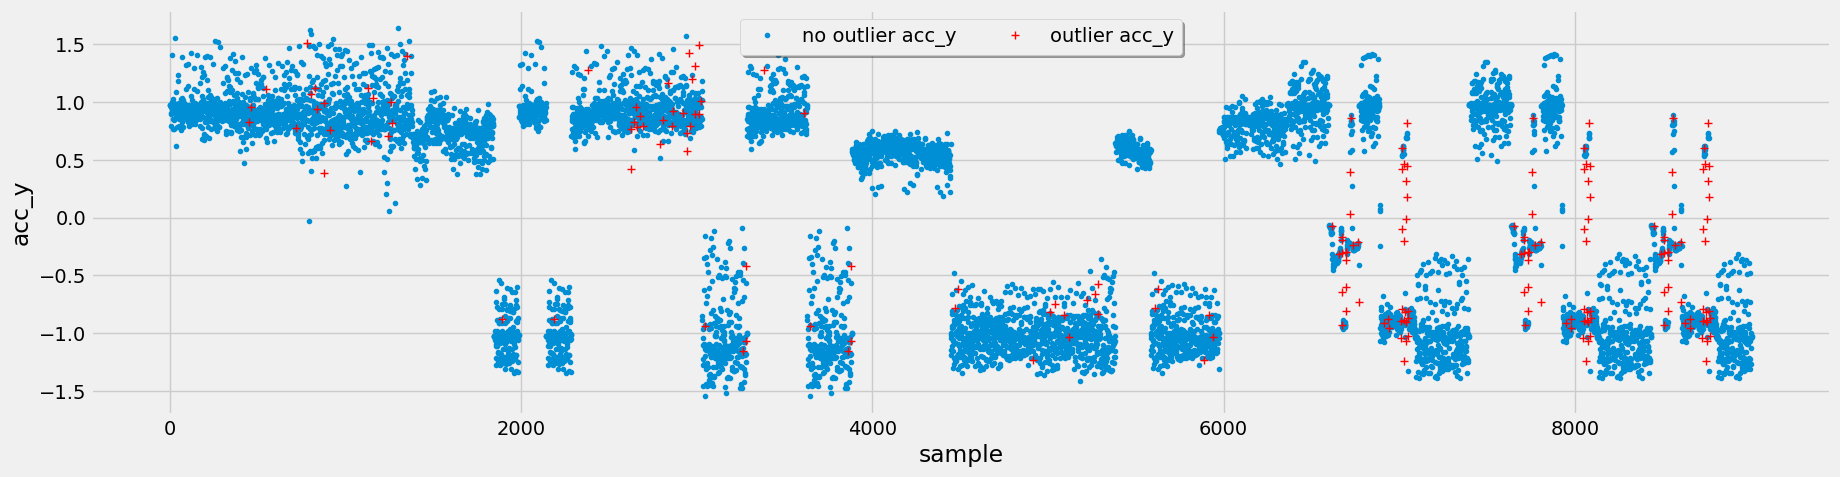

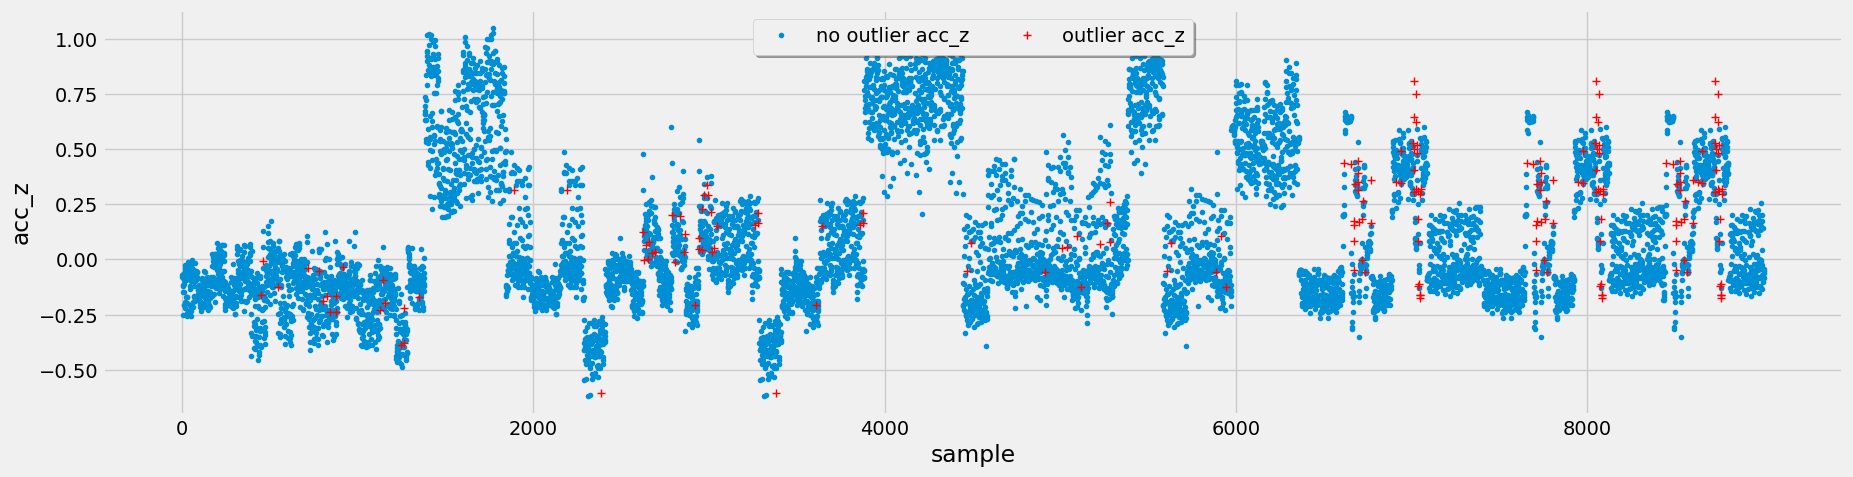

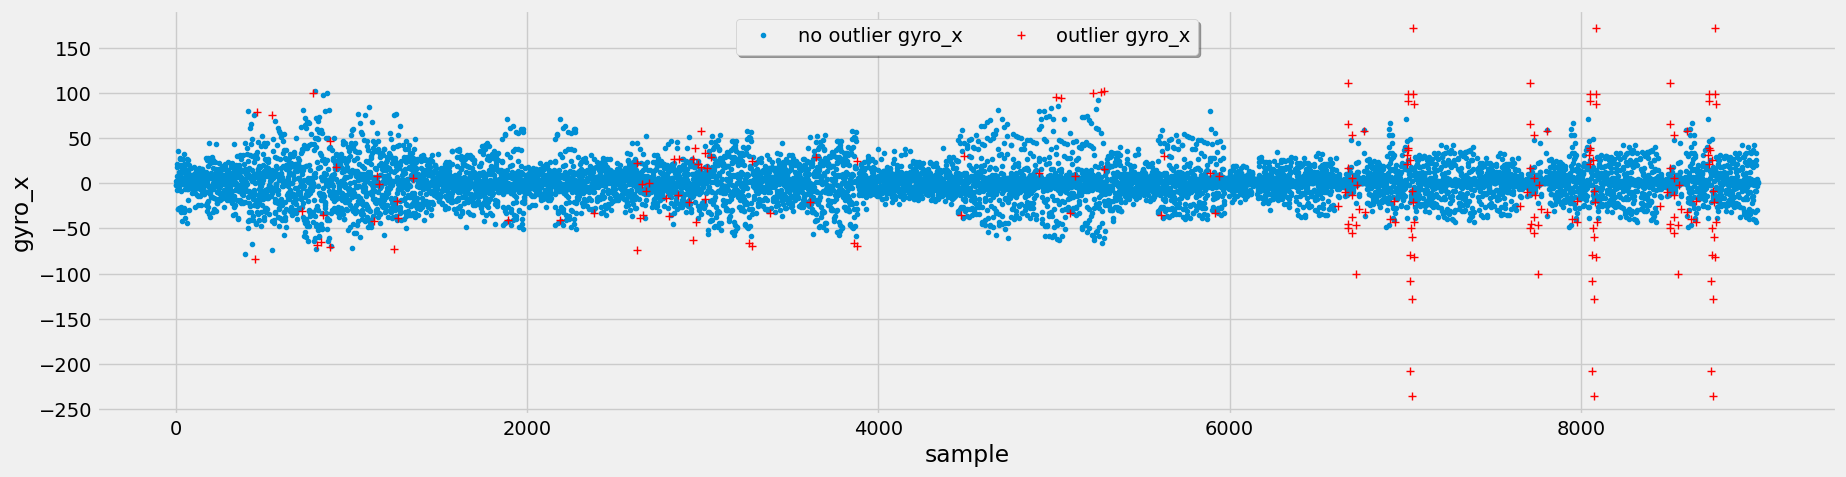

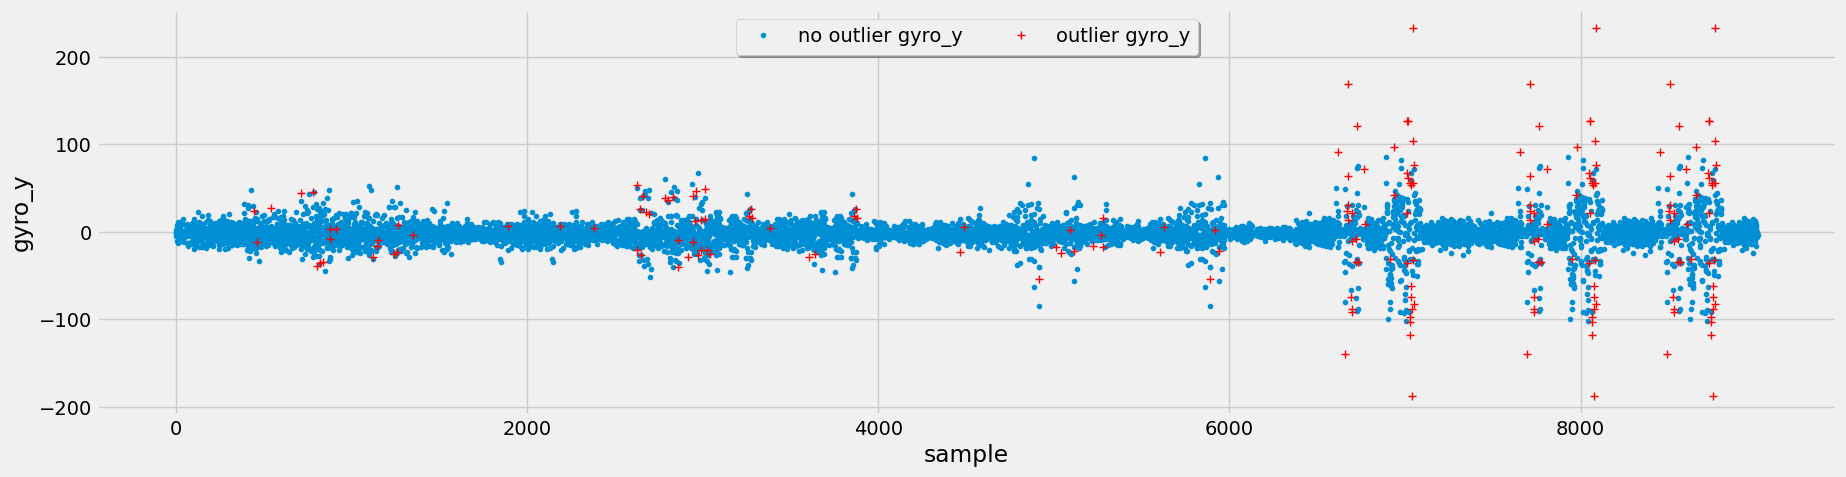

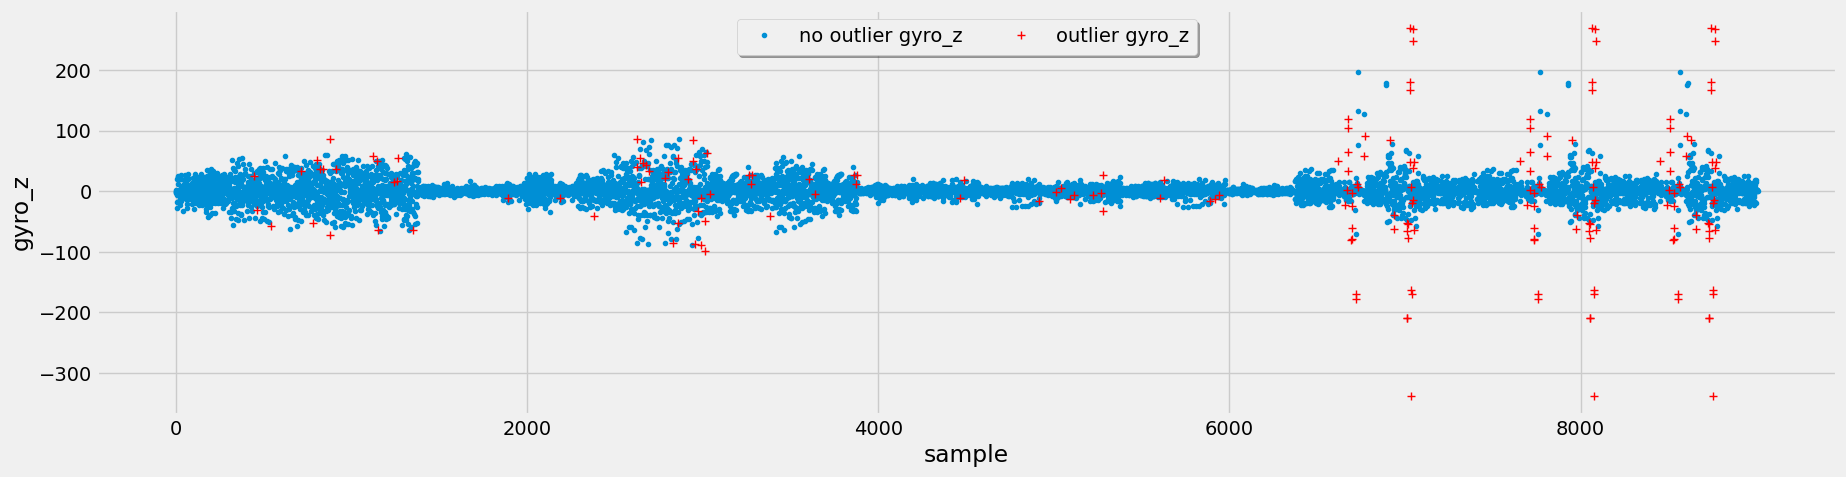

In [68]:
dataset = mark_outliers_lof(df, outlier_cols)
for col in outlier_cols:
    plot_binary_outliers(dataset, col, 'lof_outlier', reset_index=True)

> NOTE: Think about which approach is better in this case, distribution-based per column OR distance-based including all columns.

## Check outliers grouped by exercies (label)

Try all three approaches on each exercise label and compare the results.

### IQR

Quite many datapoints are detected as outliers. This method seems strict.

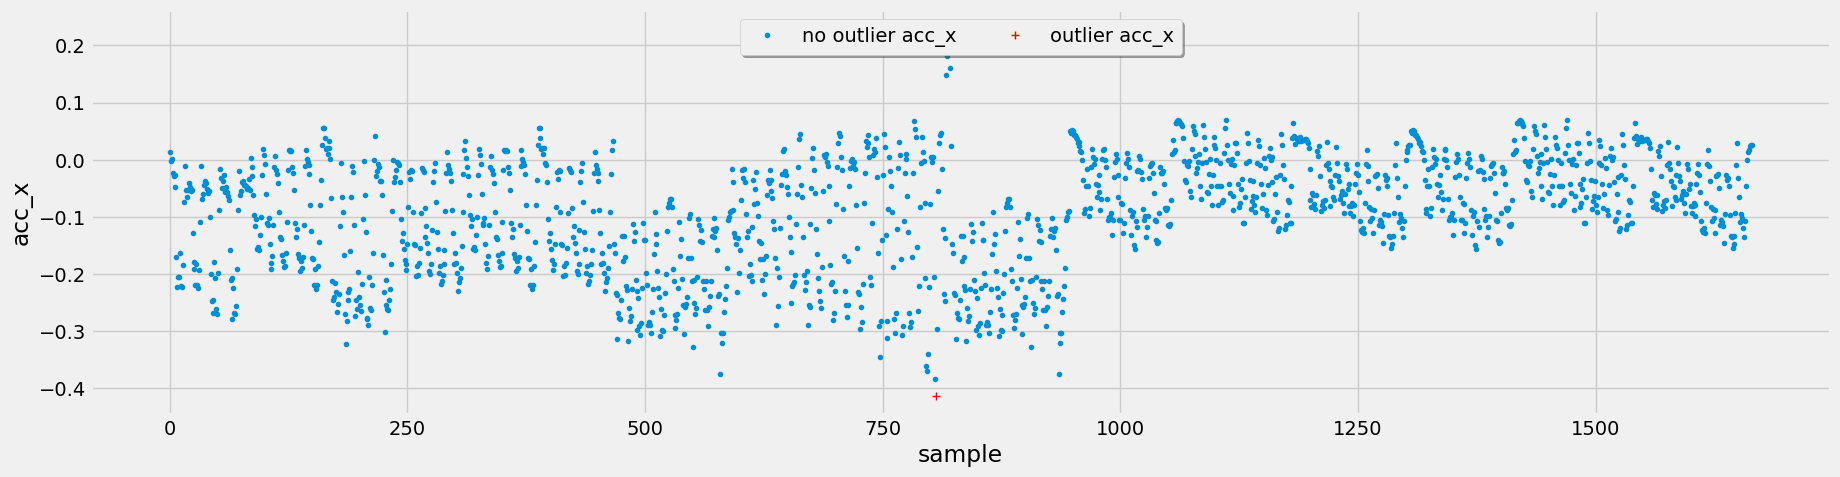

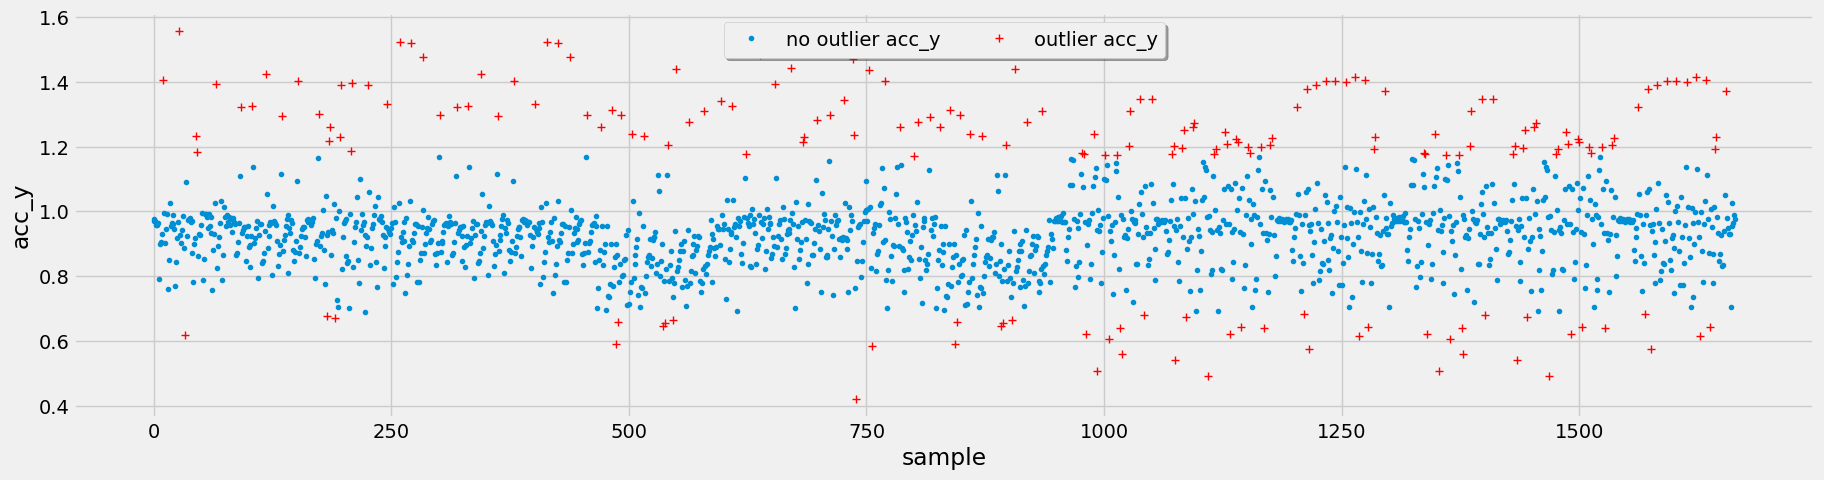

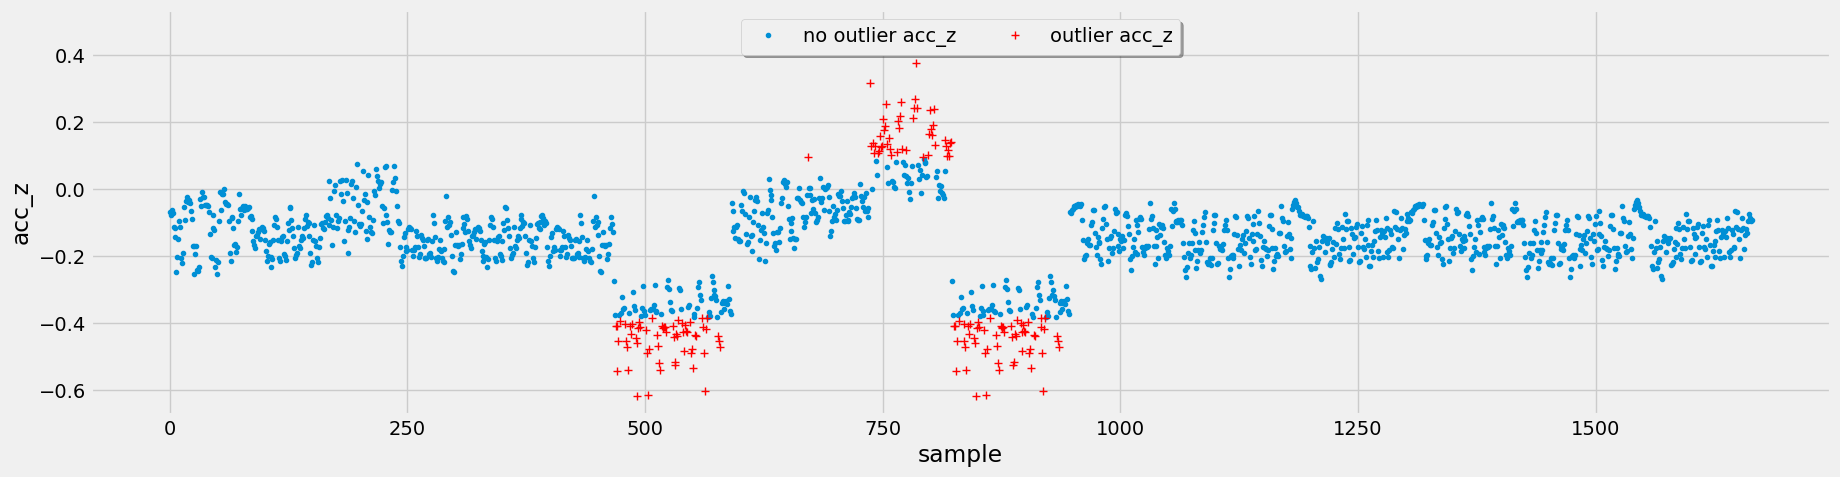

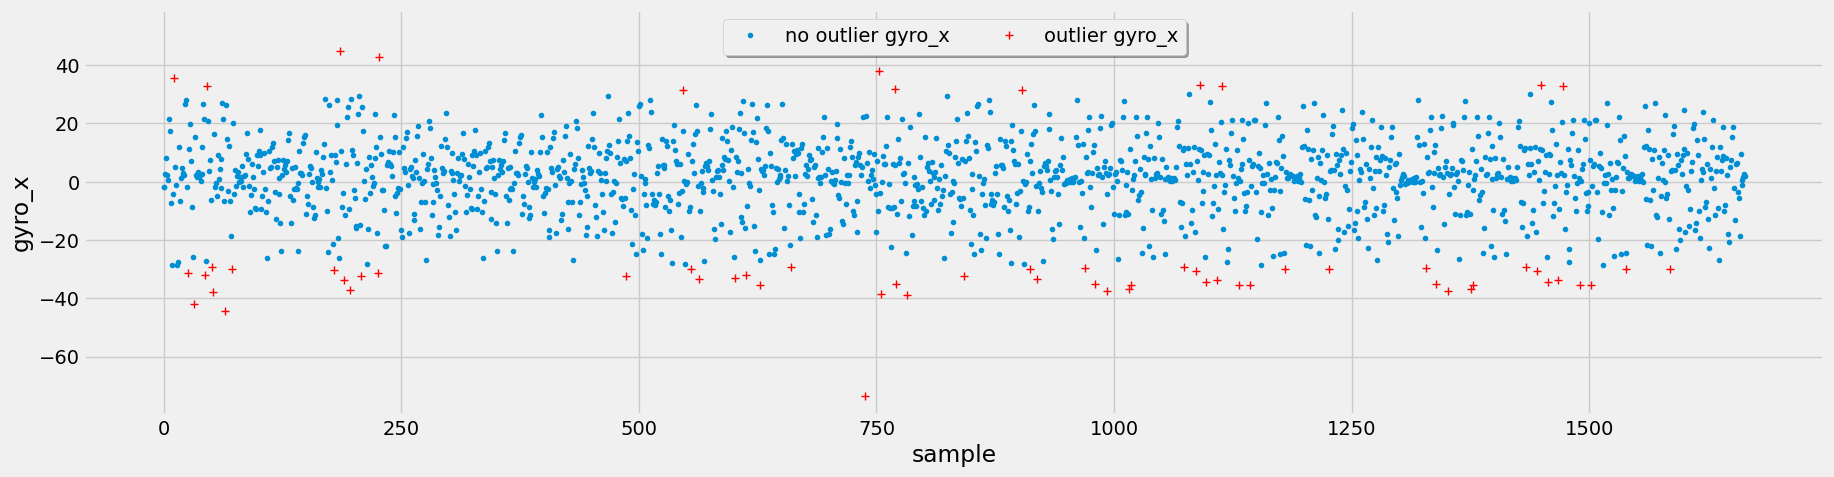

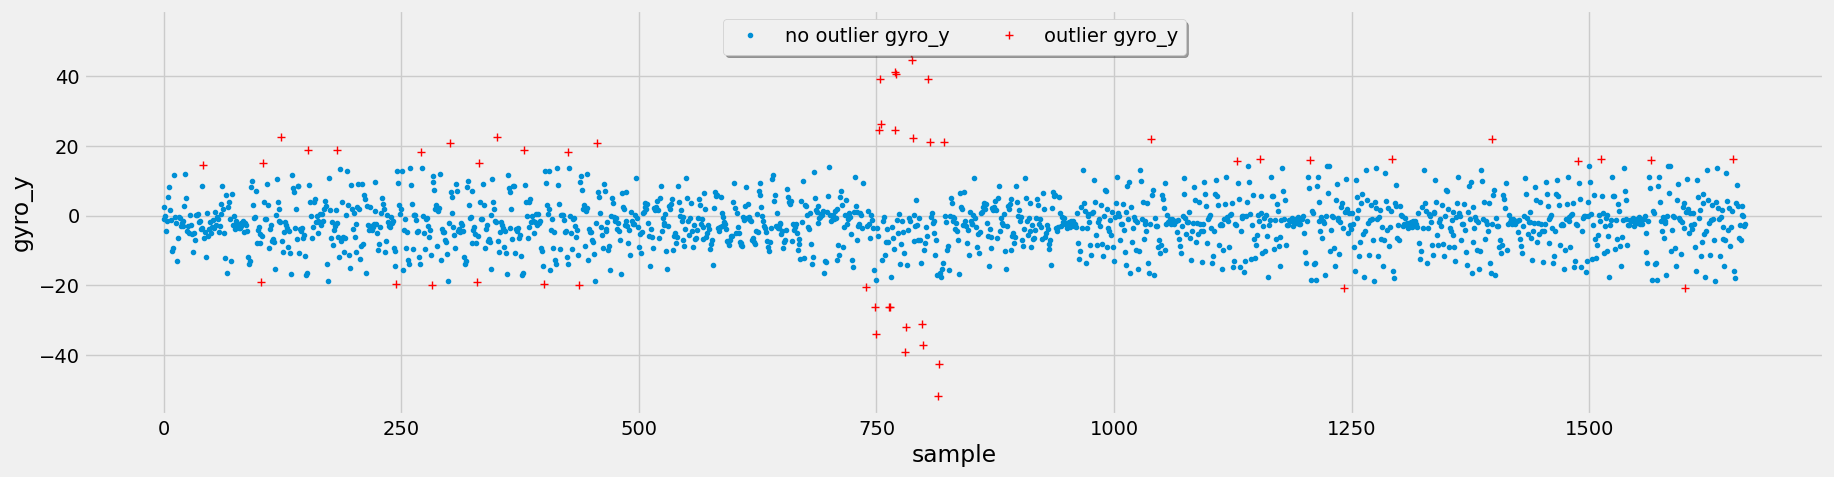

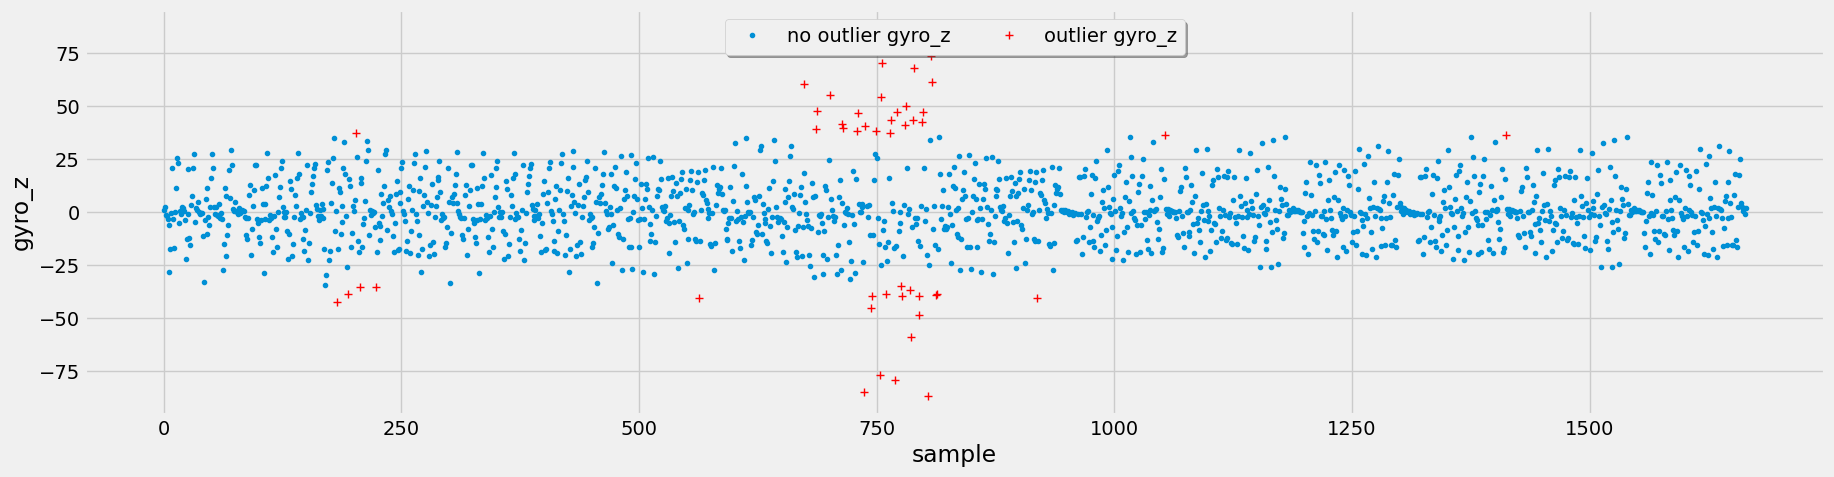

In [74]:
label = 'bench'
for col in outlier_cols:
    dataset = mark_outliers_iqr(df[df['label']==label], col)
    plot_binary_outliers(dataset, col, col+'_outlier', reset_index=True)

### Chauvenet's Criterion

Relatively tiny number of data points are detected as outliers when they are obviously away from others.

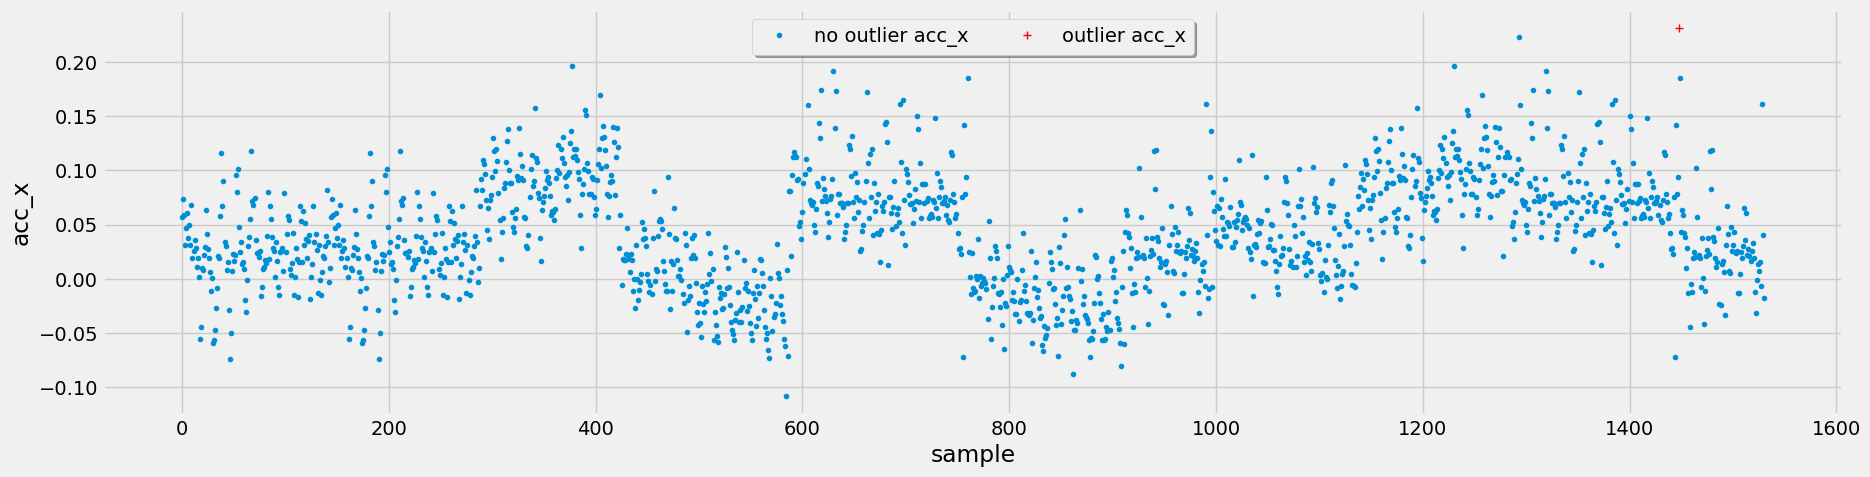

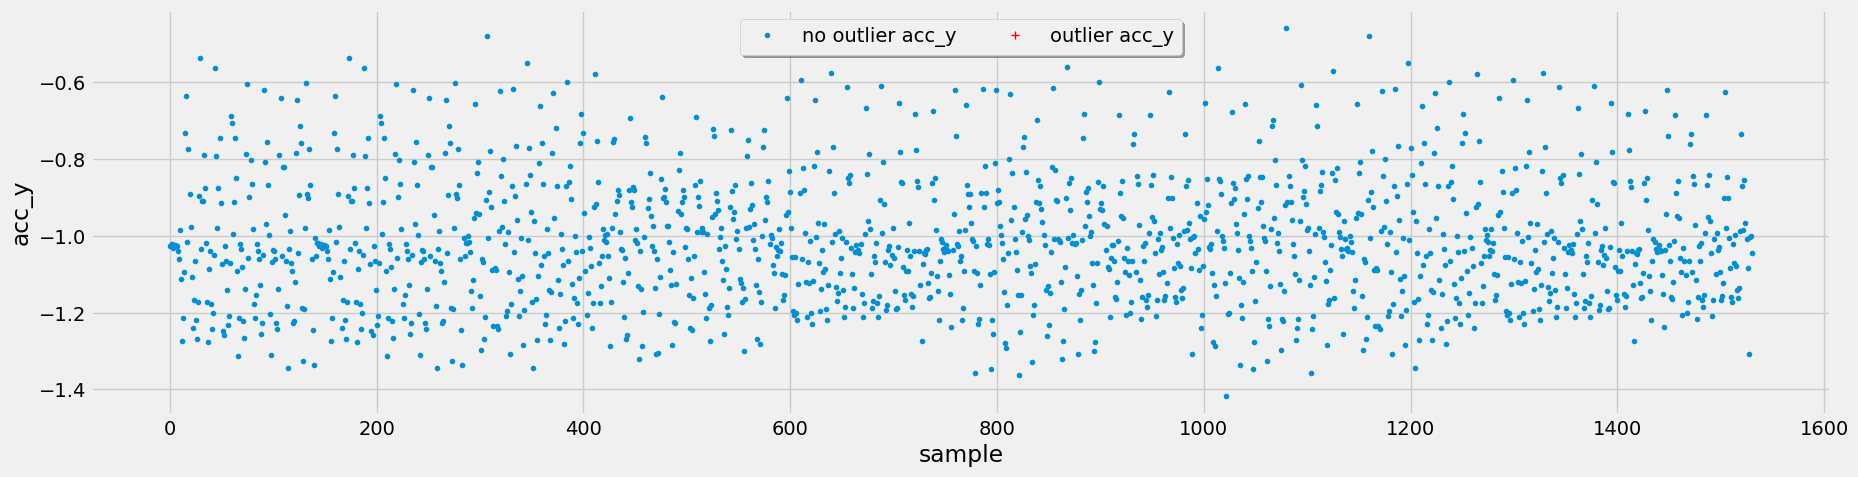

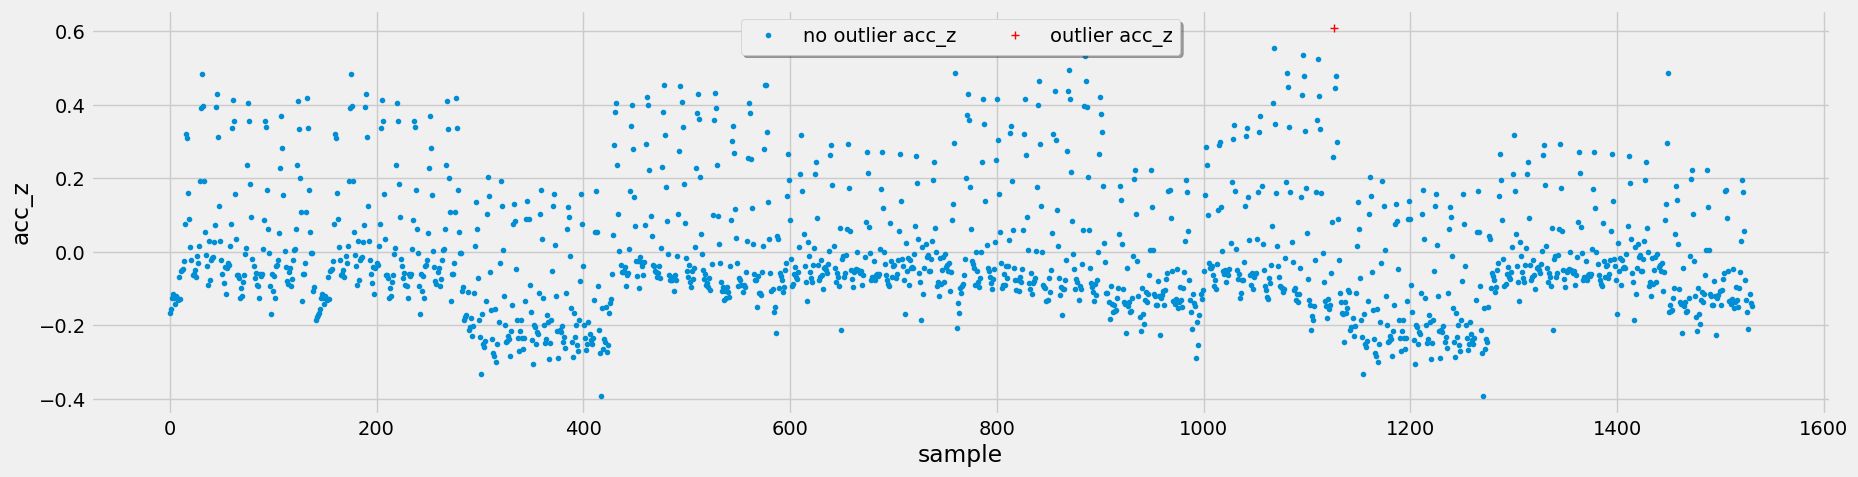

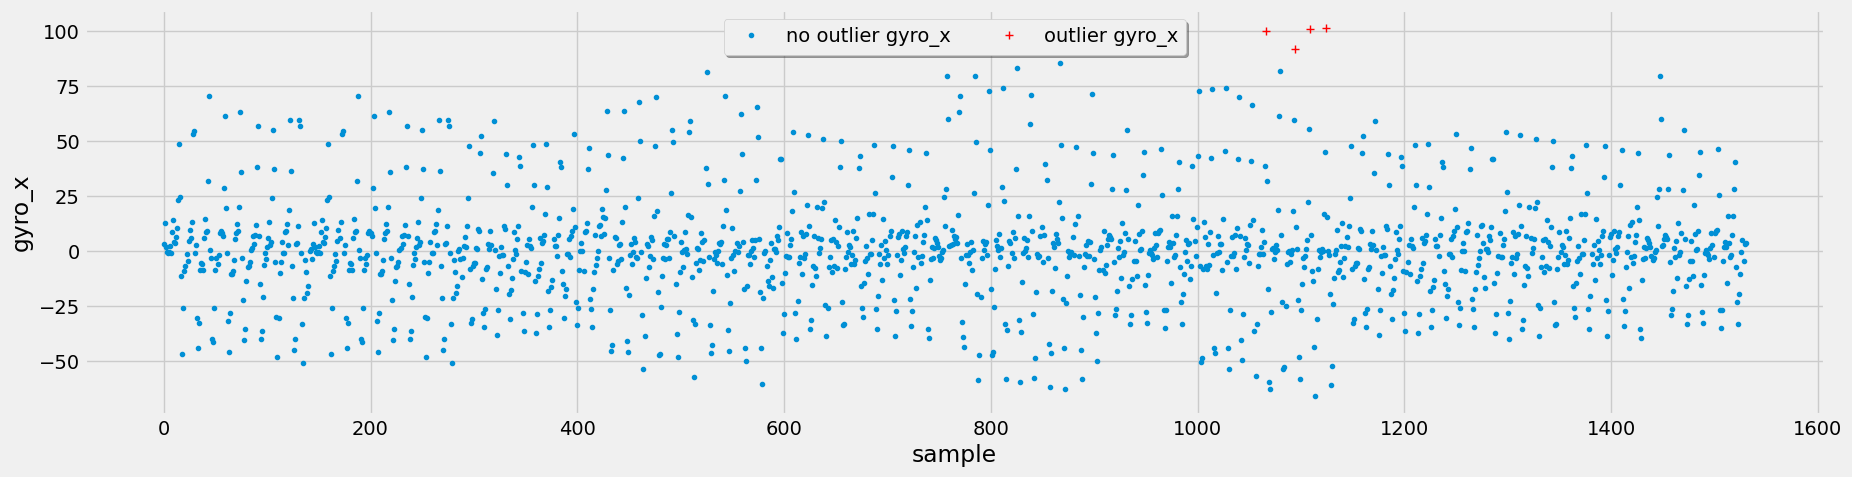

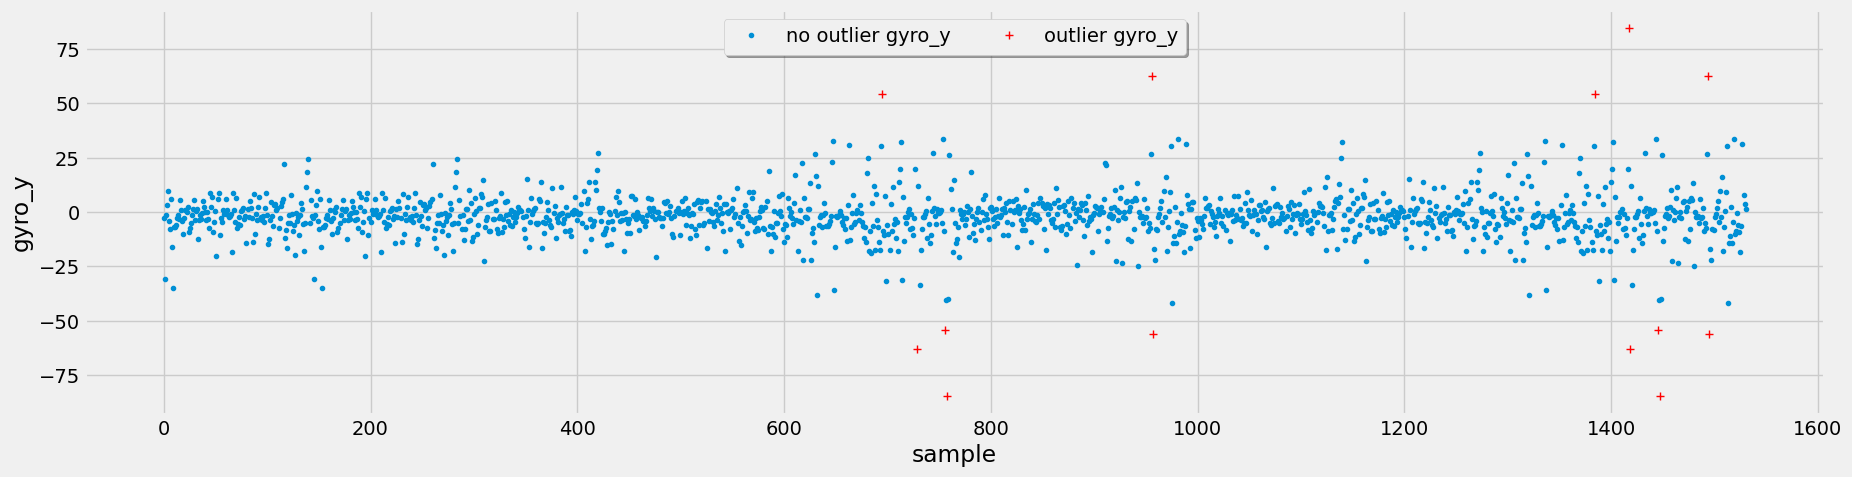

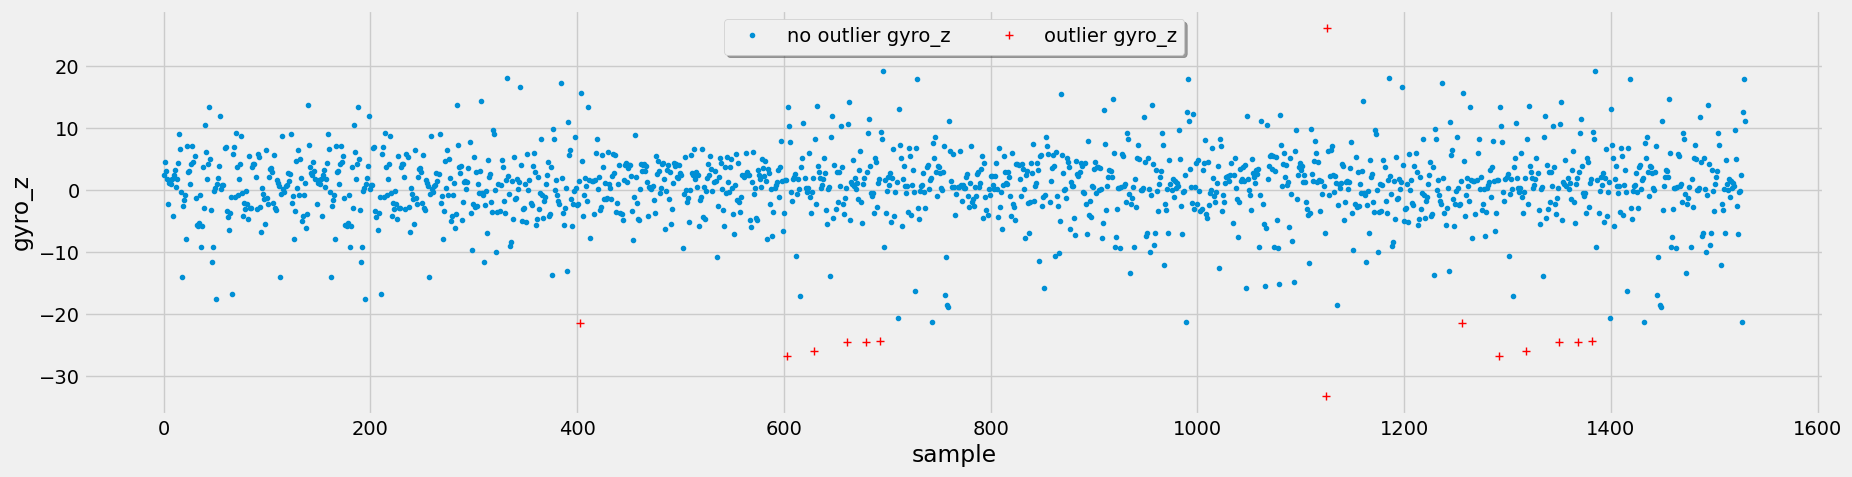

In [149]:
label = 'dead'
for col in outlier_cols:
    dataset = mark_outliers_chauvenet(df[df['label']==label], col)
    plot_binary_outliers(dataset, col, col+'_outlier', reset_index=True)

### Local Outlier Factor

As outliers are detected considering all 6 features, why those data points are outliers isn't obvious when exploring each column separately.

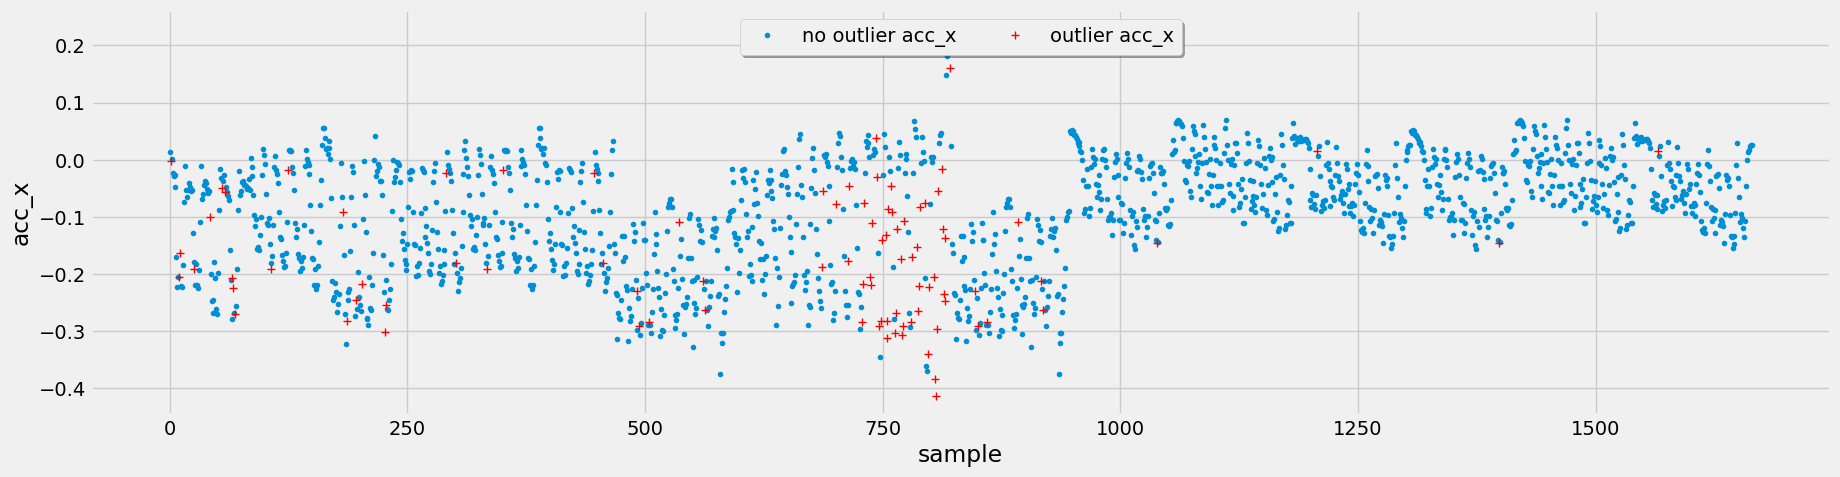

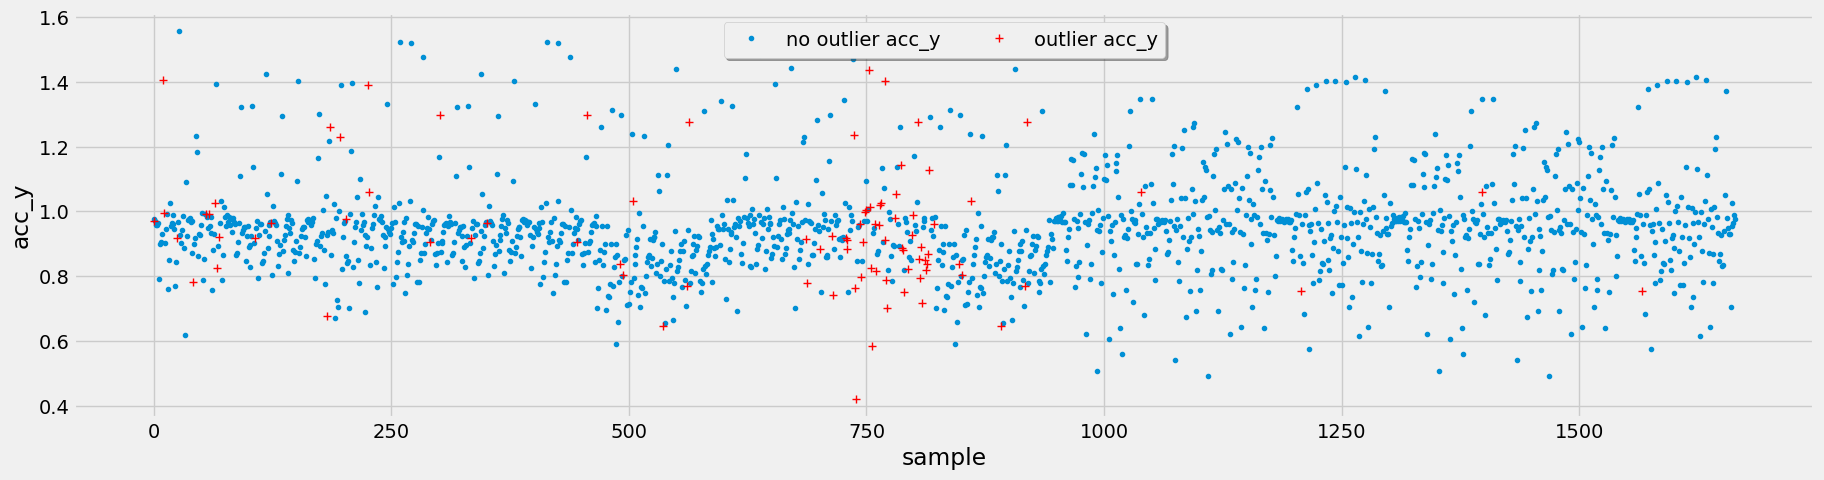

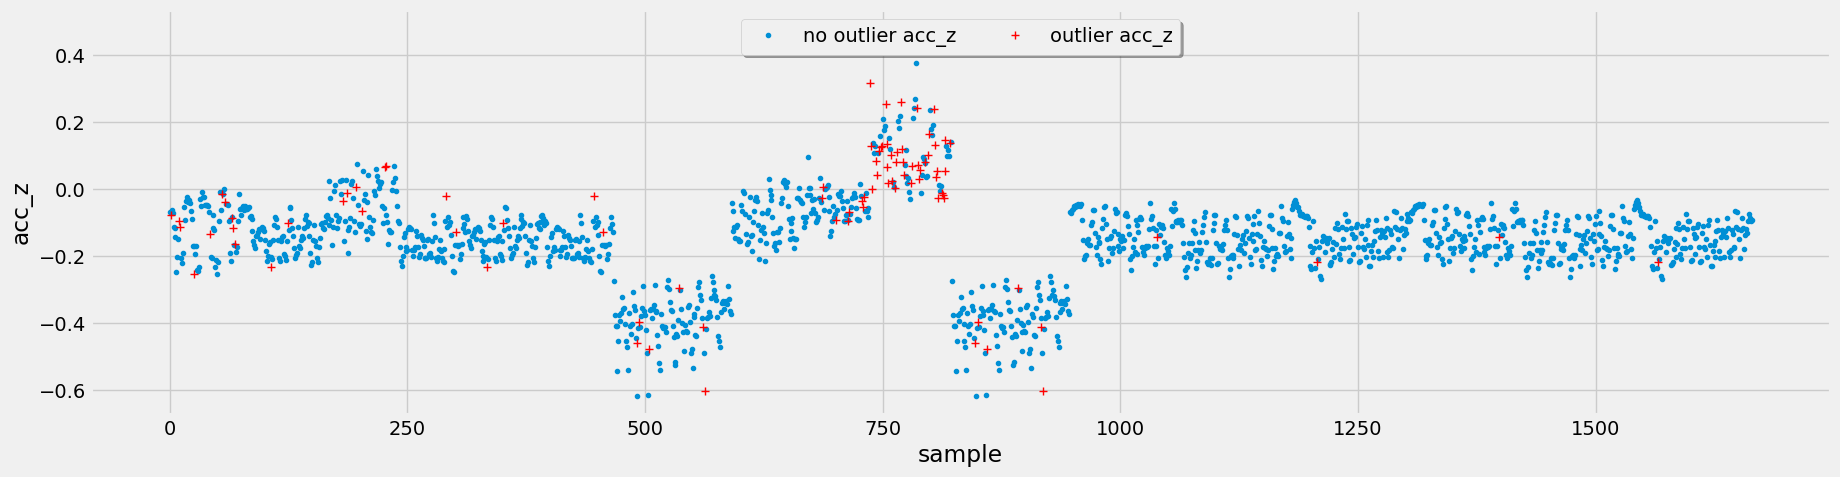

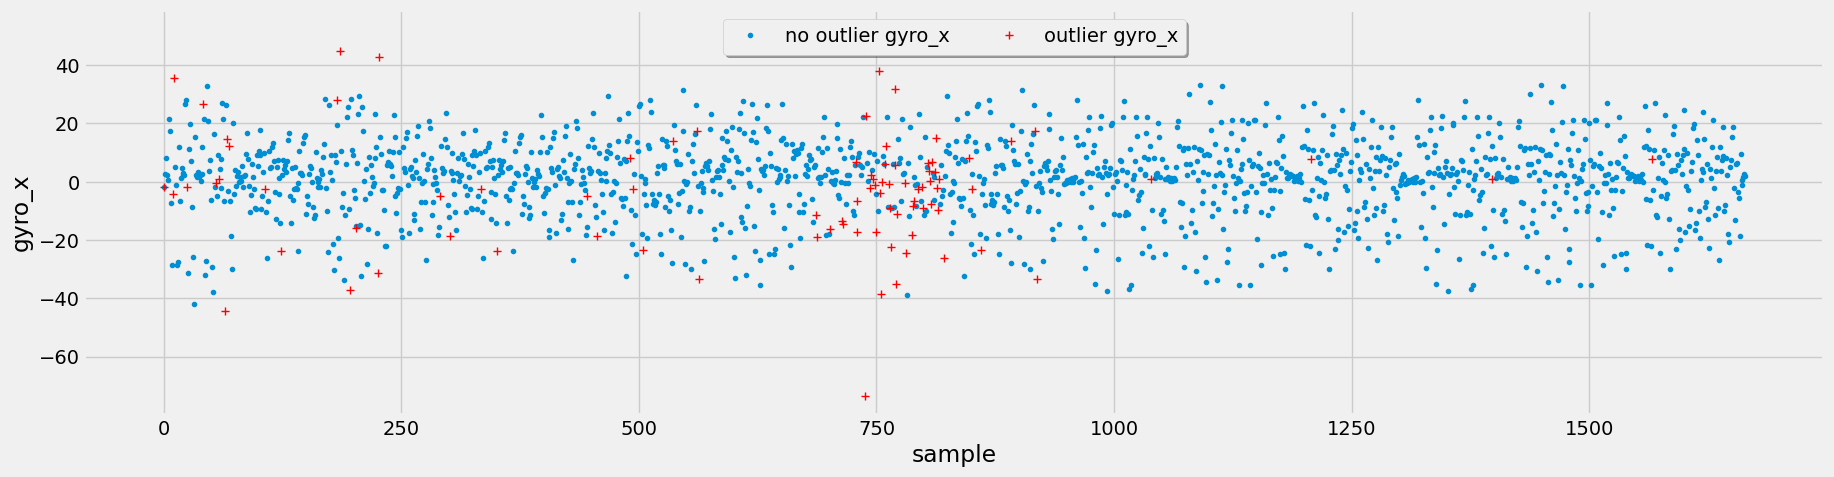

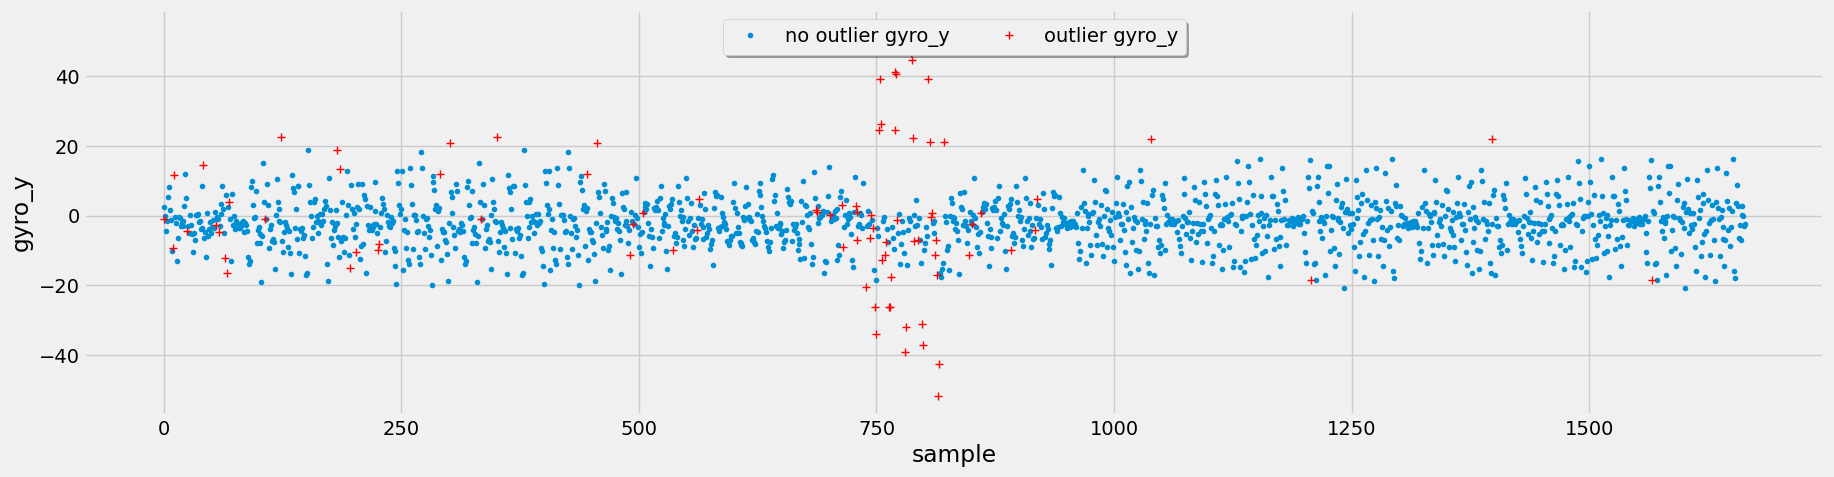

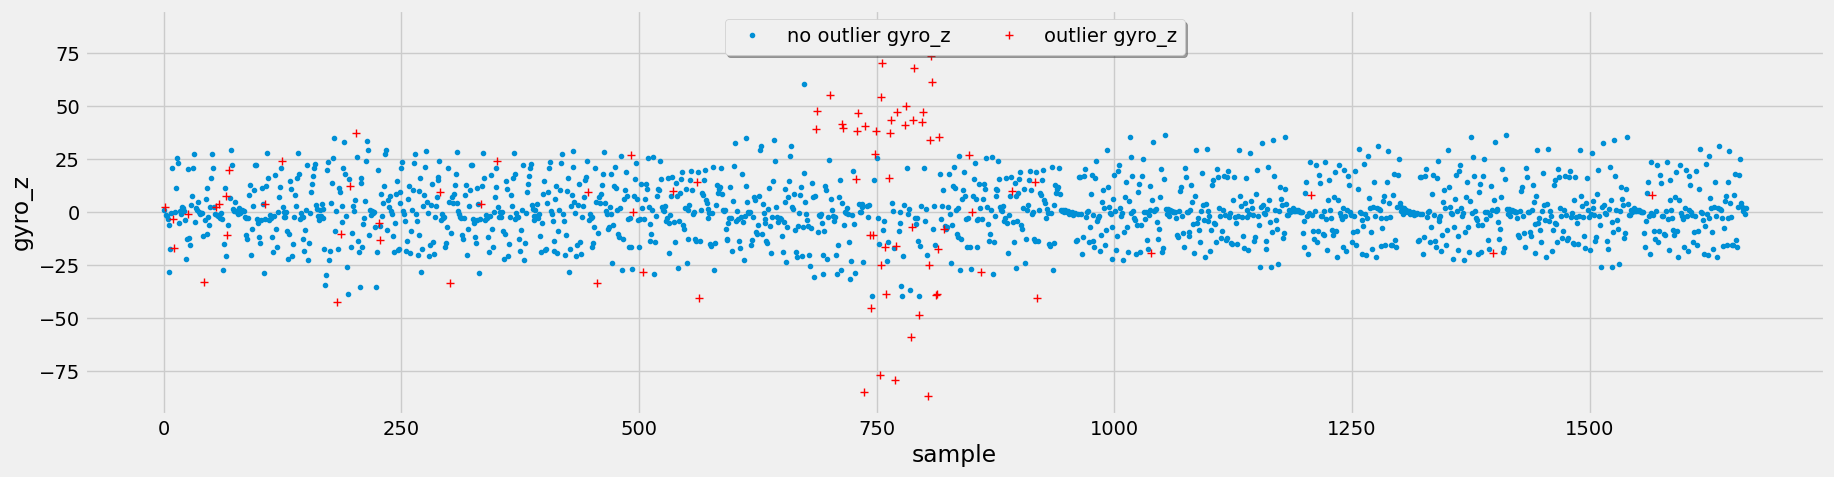

In [91]:
label = 'bench'
dataset = mark_outliers_lof(df[df['label']==label], outlier_cols)
for col in outlier_cols:
    plot_binary_outliers(dataset, col, 'lof_outlier', reset_index=True)

## Choose method and handle outliers

Choose **Chauvenet's Criterion** for our approach and decide how to process the outliers (remove, impute, etc.). Here, we will transform those outliers to `NaN` and do further process later.

### Transform on single column

In [116]:
col = 'gyro_z'
label = 'ohp'
dataset = mark_outliers_chauvenet(df[df['label']==label], col)
dataset.loc[dataset[col+'_outlier'], col] = np.nan
dataset.info()      # 1 null value in gyro_z

<class 'pandas.DataFrame'>
DatetimeIndex: 1676 entries, 2019-01-11 15:38:55 to 2019-01-15 13:55:57.400000
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   acc_x           1676 non-null   float64
 1   acc_y           1676 non-null   float64
 2   acc_z           1676 non-null   float64
 3   gyro_x          1676 non-null   float64
 4   gyro_y          1676 non-null   float64
 5   gyro_z          1675 non-null   float64
 6   participant     1676 non-null   str    
 7   label           1676 non-null   str    
 8   category        1676 non-null   str    
 9   set             1676 non-null   int64  
 10  gyro_z_outlier  1676 non-null   bool   
dtypes: bool(1), float64(6), int64(1), str(3)
memory usage: 145.7 KB


### Transform all columns

In [145]:
outliers_nan_df = df.copy()

for col in outlier_cols:
    for label in df['label'].unique():
        dataset = mark_outliers_chauvenet(df[df['label']==label], col)
        dataset.loc[dataset[col+'_outlier'], col] = np.nan
        # Update the column in the outliers_nan_df dataframe
        outliers_nan_df.loc[outliers_nan_df['label']==label, col] = dataset[col]
        n_outliers = dataset[col+'_outlier'].sum()
        print(f'Removed {n_outliers} outliers from {col} column for {label} label')
        print('-------------------------------------------------------------------------')
    print('=============================================================================')

Removed 0 outliers from acc_x column for bench label
-------------------------------------------------------------------------
Removed 2 outliers from acc_x column for ohp label
-------------------------------------------------------------------------
Removed 0 outliers from acc_x column for squat label
-------------------------------------------------------------------------
Removed 2 outliers from acc_x column for dead label
-------------------------------------------------------------------------
Removed 0 outliers from acc_x column for row label
-------------------------------------------------------------------------
Removed 0 outliers from acc_x column for rest label
-------------------------------------------------------------------------
Removed 5 outliers from acc_y column for bench label
-------------------------------------------------------------------------
Removed 6 outliers from acc_y column for ohp label
------------------------------------------------------------------

In [150]:
outliers_nan_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   acc_x        9005 non-null   float64
 1   acc_y        8998 non-null   float64
 2   acc_z        8999 non-null   float64
 3   gyro_x       8984 non-null   float64
 4   gyro_y       8938 non-null   float64
 5   gyro_z       8945 non-null   float64
 6   participant  9009 non-null   str    
 7   label        9009 non-null   str    
 8   category     9009 non-null   str    
 9   set          9009 non-null   int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 1.0 MB


### Export the dataframe

In [ ]:
outliers_nan_df.to_pickle('../../data/interim/02_chauvenet_outliers_processed.pkl')